# Exploratory Data Analysis & Visualization - Project 2
This notebook loads the SD-WAN measurement dataset, visualizes the delay time-series, highlights packet loss events (delay = -1), and checks the correlation between delay increases and packet losses.

In [9]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Define Paths and Load Data

In [10]:
DATASET_DIR = 'dataset'
FIRST_WINDOW_DIR = os.path.join(DATASET_DIR, 'first_capture_window')

# Let's load CPE A -> CPE B paths for both Fiber and Mobile (4G)
fiber_file = os.path.join(FIRST_WINDOW_DIR, 'cpe_b-cpe_a-fiber.csv')
mobile_file = os.path.join(FIRST_WINDOW_DIR, 'cpe_b-cpe_a-mobile.csv')

df_fiber = pd.read_csv(fiber_file, parse_dates=['time'])
df_mobile = pd.read_csv(mobile_file, parse_dates=['time'])

print(f"Fiber Data: {df_fiber.shape[0]} rows")
print(df_fiber.head(10))

print(f"\nMobile Data: {df_mobile.shape[0]} rows")
print(df_mobile.head(10))

Fiber Data: 113441 rows
                     time  delay_ms
0 2025-03-05 12:26:00.749   15.1341
1 2025-03-05 12:26:01.749   14.3523
2 2025-03-05 12:26:02.750   13.2537
3 2025-03-05 12:26:03.750   18.4053
4 2025-03-05 12:26:04.759   25.0196
5 2025-03-05 12:26:05.759   13.7595
6 2025-03-05 12:26:06.752   57.8543
7 2025-03-05 12:26:07.753   16.9064
8 2025-03-05 12:26:08.755   13.2828
9 2025-03-05 12:47:31.445   -1.0000

Mobile Data: 113441 rows
                     time  delay_ms
0 2025-03-05 12:26:00.749   71.9295
1 2025-03-05 12:26:01.749   71.2723
2 2025-03-05 12:26:02.750   71.2087
3 2025-03-05 12:26:03.749   71.5144
4 2025-03-05 12:26:04.759   70.3835
5 2025-03-05 12:26:05.759   61.2077
6 2025-03-05 12:26:06.753   49.3593
7 2025-03-05 12:26:07.753   67.3919
8 2025-03-05 12:26:08.755   66.7227
9 2025-03-05 12:47:30.446   -1.0000


## 2. Basic Dataset Statistics & Packet Loss Analysis
Packet loss events are marked by `delay_ms = -1`. Let's calculate the packet loss rate and basic statistics of valid delays.

In [11]:
def analyze_packet_loss(df, label):
    total_packets = len(df)
    lost_packets = (df['delay_ms'] == -1).sum()
    loss_rate = (lost_packets / total_packets) * 100
    
    # Exclude packet losses to calculate valid delay statistics
    valid_delays = df[df['delay_ms'] != -1]['delay_ms']
    
    print(f"=== {label} ===")
    print(f"Total rows: {total_packets}")
    print(f"Packet losses (-1): {lost_packets} ({loss_rate:.4f}%)")
    print(f"Valid delay stats (ms):")
    print(f"  Mean:   {valid_delays.mean():.4f}")
    print(f"  Min:    {valid_delays.min():.4f}")
    print(f"  Max:    {valid_delays.max():.4f}")
    print(f"  Std:    {valid_delays.std():.4f}")
    print(f"  95th %: {valid_delays.quantile(0.95):.4f}")
    print(f"  99th %: {valid_delays.quantile(0.99):.4f}")
    print("=" * 30 + "\n")

analyze_packet_loss(df_fiber, "Fiber (CPE A -> B)")
analyze_packet_loss(df_mobile, "Mobile 4G (CPE A -> B)")

=== Fiber (CPE A -> B) ===
Total rows: 113441
Packet losses (-1): 33 (0.0291%)
Valid delay stats (ms):
  Mean:   14.8033
  Min:    9.5211
  Max:    625.3413
  Std:    4.4031
  95th %: 19.6225
  99th %: 28.1107

=== Mobile 4G (CPE A -> B) ===
Total rows: 113441
Packet losses (-1): 251 (0.2213%)
Valid delay stats (ms):
  Mean:   78.5779
  Min:    33.2818
  Max:    994.3062
  Std:    39.4635
  95th %: 145.1385
  99th %: 262.0759



C:\Users\Pietro Guidetti\AppData\Local\Temp\ipykernel_2600\1758627603.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data, labels=['Fiber', '4G'], patch_artist=True, showfliers=False)
C:\Users\Pietro Guidetti\AppData\Local\Temp\ipykernel_2600\1758627603.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


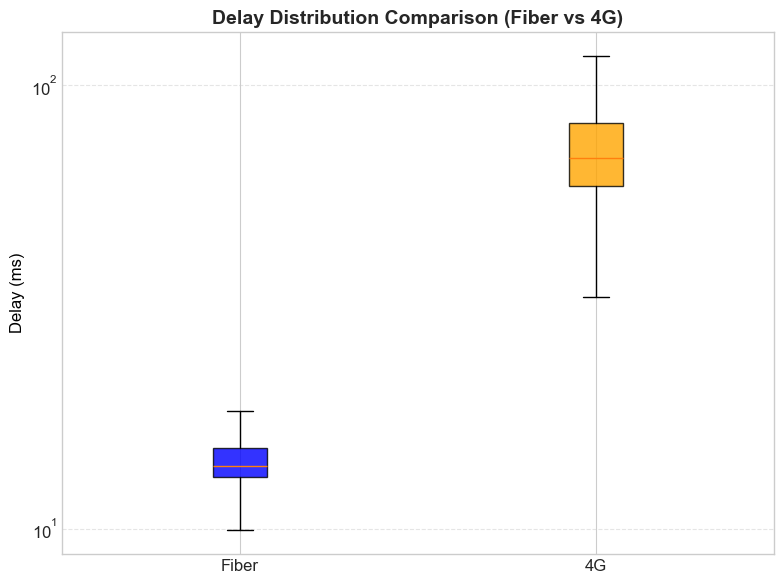

<Figure size 1200x600 with 0 Axes>

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparazione delle serie di ritardo valide (escludendo i packet loss a -1)
fiber_valid = df_fiber['delay_ms'].replace(-1, np.nan).dropna()
mobile_valid = df_mobile['delay_ms'].replace(-1, np.nan).dropna()

# 2. Creazione della figura con un singolo asse (rimossa la logica dei subplots multipli)
fig, ax = plt.subplots(figsize=(8, 6))

# 3. Creazione del boxplot
box_data = [fiber_valid, mobile_valid]
box = ax.boxplot(box_data, labels=['Fiber', '4G'], patch_artist=True, showfliers=False)

# 4. Stile dei box (Colori)
colors = ['blue', 'orange'] # Blu per Fiber, Arancione per 4G
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8) # Aggiunta una leggera trasparenza per un look più pulito


# 6. Formattazione dell'asse (Scala logaritmica e testo)
ax.set_yscale('log')
ax.set_ylabel('Delay (ms)', color='black')
ax.set_title('Delay Distribution Comparison (Fiber vs 4G)', fontsize=14, weight='bold')

# Aggiunta di una griglia orizzontale leggera per facilitare la lettura della scala logaritmica
ax.grid(True, axis='y', linestyle='--', alpha=0.5)

ax.legend()
plt.tight_layout()

plt.show()
plt.savefig('results/raw_data_visualization/boxplot_delay_comparison.png', dpi=300)

## 2.5. Statistical Distributions of Fiber and Mobile Delays
Let's compare the Probability Density Functions (PDF) and Cumulative Distribution Functions (CDF) of the delay measurements to visualize the differences in terms of baseline latency, variability (jitter), and tail behaviors. This is important to assess how similar (or non-IID) the two network types are for model training and Federated Learning aggregation.

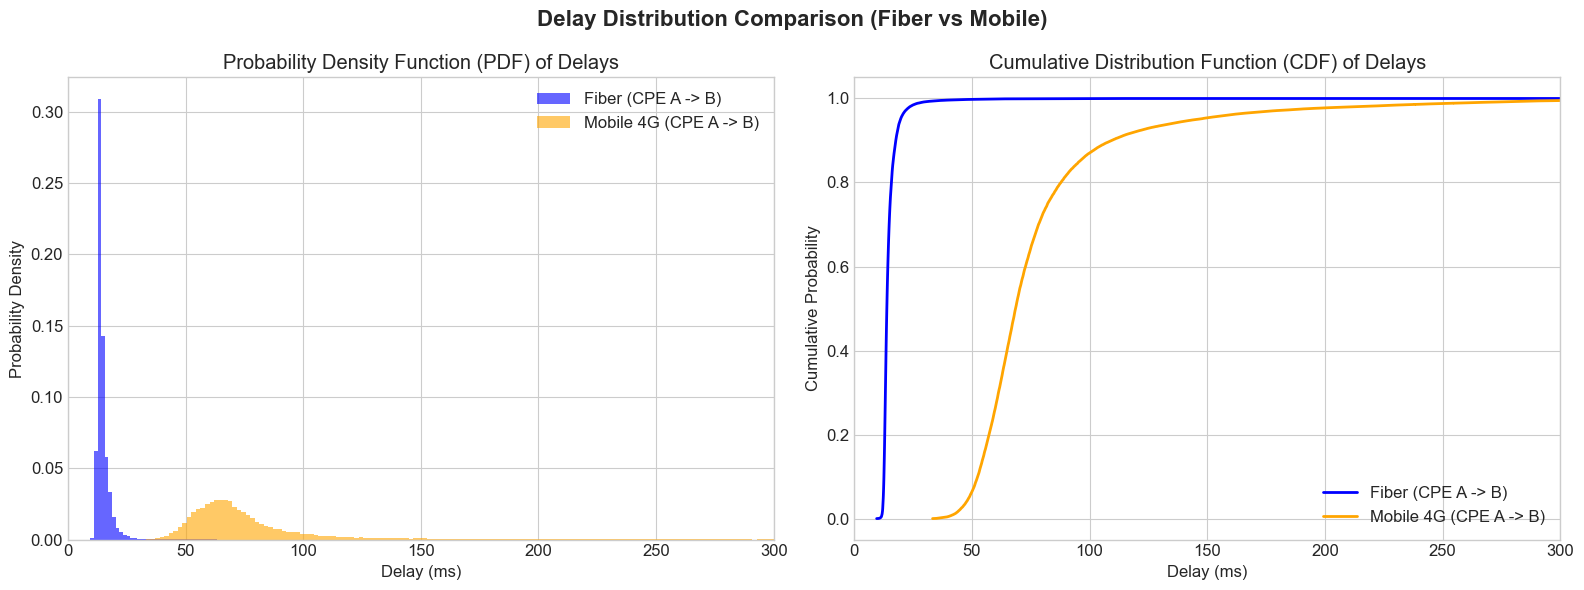

In [13]:

# Exclude packet losses (-1) for statistical plotting
fiber_delays = df_fiber[df_fiber['delay_ms'] != -1]['delay_ms']
mobile_delays = df_mobile[df_mobile['delay_ms'] != -1]['delay_ms']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Probability Density Function (PDF)
axes[0].hist(fiber_delays, bins=400, density=True, alpha=0.6, label='Fiber (CPE A -> B)', color='blue')
axes[0].hist(mobile_delays, bins=500, density=True, alpha=0.6, label='Mobile 4G (CPE A -> B)', color='orange')
axes[0].set_title('Probability Density Function (PDF) of Delays')
axes[0].set_xlabel('Delay (ms)')
axes[0].set_ylabel('Probability Density')
axes[0].set_xlim(0, 300) 
axes[0].legend()

# Plot 2: Cumulative Distribution Function (CDF) - Approccio ECDF
# ordering data
x_fiber = np.sort(fiber_delays)
x_mobile = np.sort(mobile_delays)

# create y axis, pronabably using the formula for ECDF
y_fiber = np.arange(1, len(x_fiber) + 1) / len(x_fiber) 
y_mobile = np.arange(1, len(x_mobile) + 1) / len(x_mobile)

axes[1].plot(x_fiber, y_fiber, label='Fiber (CPE A -> B)', color='blue', linewidth=2)
axes[1].plot(x_mobile, y_mobile, label='Mobile 4G (CPE A -> B)', color='orange', linewidth=2)

axes[1].set_title('Cumulative Distribution Function (CDF) of Delays')
axes[1].set_xlabel('Delay (ms)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].set_xlim(0, 300) 
axes[1].legend(loc='lower right')

plt.suptitle('Delay Distribution Comparison (Fiber vs Mobile)', fontsize=16, weight='bold')
plt.tight_layout()

plt.savefig('results/raw_data_visualization/delay_distribution_comparison.png', dpi=300)
plt.show()

## 3. Visualize Raw Delay Time Series
Let's plot the latency values and display where packet losses occur.

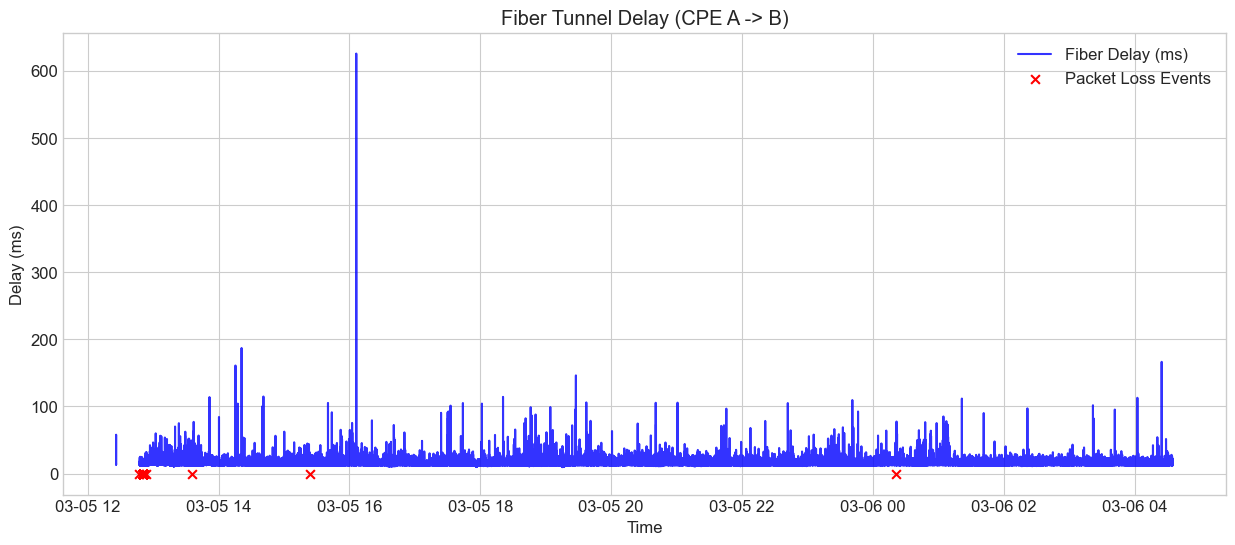

In [14]:
# Plotting Fiber delay
plt.figure(figsize=(15, 6))
plt.plot(df_fiber['time'], df_fiber['delay_ms'].replace(-1, np.nan), label='Fiber Delay (ms)', color='blue', alpha=0.8)

# Highlight packet losses as red x
losses = df_fiber[df_fiber['delay_ms'] == -1]
plt.scatter(losses['time'], [0] * len(losses), color='red', marker='x', label='Packet Loss Events', s=40, zorder=5)

plt.title('Fiber Tunnel Delay (CPE A -> B)')
plt.xlabel('Time')
plt.ylabel('Delay (ms)')
plt.legend()
plt.savefig('results/raw_data_visualization/fiber_delay_time_series.png', dpi=300)
plt.show()

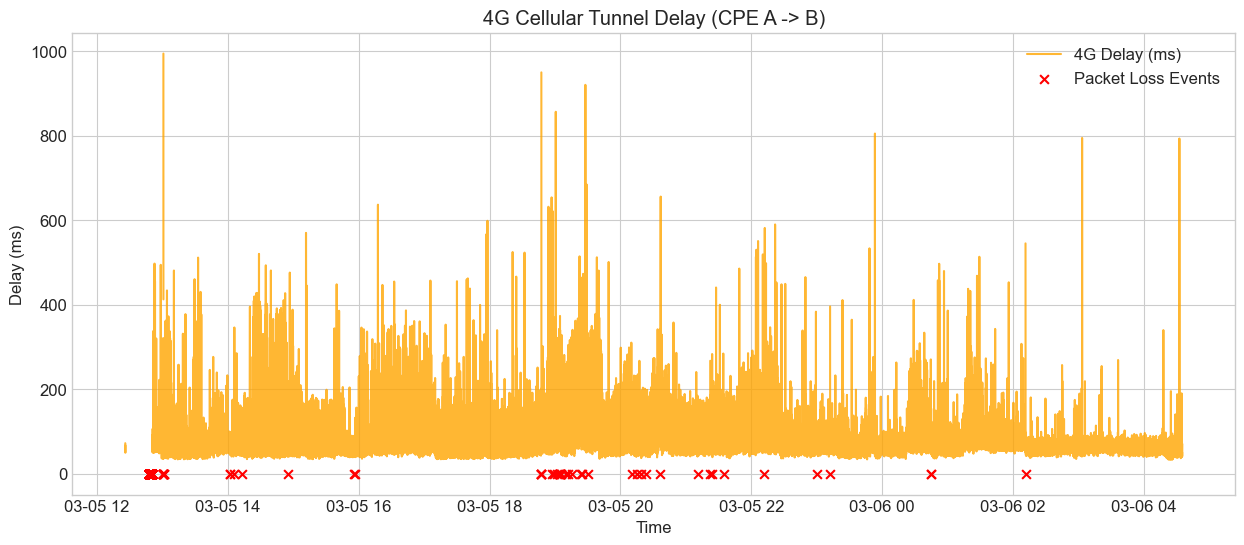

In [15]:
# Plotting Mobile delay
plt.figure(figsize=(15, 6))
plt.plot(df_mobile['time'], df_mobile['delay_ms'].replace(-1, np.nan), label='4G Delay (ms)', color='orange', alpha=0.8)

# Highlight packet losses as red x
losses_m = df_mobile[df_mobile['delay_ms'] == -1]
plt.scatter(losses_m['time'], [0] * len(losses_m), color='red', marker='x', label='Packet Loss Events', s=40, zorder=5)

plt.title('4G Cellular Tunnel Delay (CPE A -> B)')
plt.xlabel('Time')
plt.ylabel('Delay (ms)')
plt.legend()
plt.savefig('results/raw_data_visualization/4g_delay_time_series.png', dpi=300)
plt.show()

Fiber (CPE A -> B):
  Loss: 33 (0.0291%)
  No Loss: 113408 (99.9709%)

4G Mobile (CPE A -> B):
  Loss: 251 (0.2213%)
  No Loss: 113190 (99.7787%)



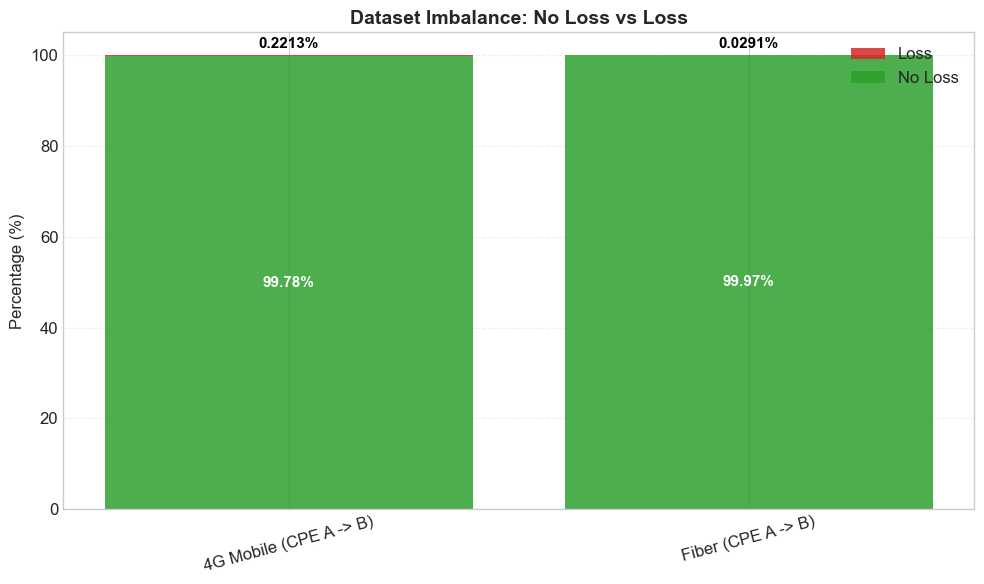

In [ ]:
# Dictionary containing your source DataFrames
datasets = {
    'Fiber (CPE A -> B)': df_fiber,
    '4G Mobile (CPE A -> B)': df_mobile
}

summary_rows = []
for dataset_name, frame in datasets.items():
    total_rows = len(frame)
    loss_rows = int((frame['delay_ms'] == -1).sum())
    no_loss_rows = total_rows - loss_rows

    loss_pct = (loss_rows / total_rows) * 100 if total_rows else 0
    no_loss_pct = (no_loss_rows / total_rows) * 100 if total_rows else 0

    # Populating data for plotting
    summary_rows.append({
        'dataset': dataset_name,
        'class': 'Loss',
        'percentage': loss_pct
    })
    summary_rows.append({
        'dataset': dataset_name,
        'class': 'No Loss',
        'percentage': no_loss_pct
    })

    print(f'{dataset_name}:')
    print(f'  Loss: {loss_rows} ({loss_pct:.4f}%)')
    print(f'  No Loss: {no_loss_rows} ({no_loss_pct:.4f}%)')
    print()

# Create the summary DataFrame
imbalance_df = pd.DataFrame(summary_rows)

# Generate pivot with 'No Loss' as the first column and 'Loss' as the second.
# This forces 'Loss' to be rendered at the bottom (base) and 'No Loss' on top of it.
pivot_df = imbalance_df.pivot(index='dataset', columns='class', values='percentage')[['No Loss', 'Loss']]

fig, ax = plt.subplots(figsize=(10, 6))

# Coherent color mapping: index 0 is 'No Loss' (Green), index 1 is 'Loss' (Red)
colors = ['#2ca02c', '#d62728']
bottom = np.zeros(len(pivot_df))

for idx, class_name in enumerate(pivot_df.columns):
    values = pivot_df[class_name].values
    bars = ax.bar(pivot_df.index, values, bottom=bottom, label=class_name, color=colors[idx], alpha=0.85)
    
    for bar, value in zip(bars, values):
        if value > 0:
            # If Loss percentage is very small, lift the text above the X-axis 
            # and dye it black to avoid clipped text or poor contrast
            if class_name == 'Loss' and value < 4.0:
                y_pos = bar.get_y() + bar.get_height() + 1.0  # Placed slightly above the micro-bar
                text_color = 'black'
                va_align = 'bottom'
                # Show 4 decimal places if value is below 1% for better precision
                label_text = f'{value:.4f}%' if value < 1 else f'{value:.2f}%'
            else:
                y_pos = bar.get_y() + bar.get_height() / 2    # Vertically centered for normal bars
                text_color = 'white'
                va_align = 'center'
                label_text = f'{value:.2f}%'
                
            ax.text(bar.get_x() + bar.get_width() / 2, y_pos, label_text,
                    ha='center', va=va_align, color=text_color, fontsize=11, fontweight='bold')
            
    bottom += values

# Configure axis limits and labels
ax.set_ylim(0, 105)  # Raised slightly above 100 to give breathing room for top labels
ax.set_ylabel('Percentage (%)')
ax.set_title('Dataset Imbalance: No Loss vs Loss', fontsize=14, weight='bold')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], loc='upper right')

ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig('results/raw_data_visualization/dataset_imbalance_loss_vs_no_loss.png', dpi=300)
plt.show()


,capture_window,csv_file,total_rows,loss_count,no_loss_count,loss_fraction,no_loss_fraction,loss_percentage,no_loss_percentage
0,First capture window,cpe_a-cpe_b-fiber.csv,57633,58,57575,58/57633,57575/57633,0.100637,99.899363
1,First capture window,cpe_a-cpe_b-mobile.csv,57633,252,57381,252/57633,57381/57633,0.437249,99.562751
2,First capture window,cpe_a-cpe_c-fiber.csv,57633,58,57575,58/57633,57575/57633,0.100637,99.899363
3,First capture window,cpe_a-cpe_c-mobile.csv,57633,177,57456,177/57633,57456/57633,0.307116,99.692884
4,First capture window,cpe_b-cpe_a-fiber.csv,113441,33,113408,33/113441,113408/113441,0.029090,99.970910
5,First capture window,cpe_b-cpe_a-mobile.csv,113441,251,113190,251/113441,113190/113441,0.221260,99.778740
6,First capture window,cpe_b-cpe_c-fiber.csv,113441,31,113410,31/113441,113410/113441,0.027327,99.972673
7,First capture window,cpe_b-cpe_c-mobile.csv,113441,398,113043,398/113441,113043/113441,0.350843,99.649157
8,First capture window,cpe_c-cpe_a-fiber.csv,56855,5,56850,5/56855,56850/56855,0.008794,99.991206
9,First capture window,cpe_c-cpe_a-mobile.csv,56855,98,56757,98/56855,56757/56855,0.172368,99.827632


Overall summary by CSV:
First capture window | cpe_a-cpe_b-fiber.csv:  Loss 58 (58/57633, 0.1006%),  No Loss 57575 (57575/57633, 99.8994%)
First capture window | cpe_a-cpe_b-mobile.csv:  Loss 252 (252/57633, 0.4372%),  No Loss 57381 (57381/57633, 99.5628%)
First capture window | cpe_a-cpe_c-fiber.csv:  Loss 58 (58/57633, 0.1006%),  No Loss 57575 (57575/57633, 99.8994%)
First capture window | cpe_a-cpe_c-mobile.csv:  Loss 177 (177/57633, 0.3071%),  No Loss 57456 (57456/57633, 99.6929%)
First capture window | cpe_b-cpe_a-fiber.csv:  Loss 33 (33/113441, 0.0291%),  No Loss 113408 (113408/113441, 99.9709%)
First capture window | cpe_b-cpe_a-mobile.csv:  Loss 251 (251/113441, 0.2213%),  No Loss 113190 (113190/113441, 99.7787%)
First capture window | cpe_b-cpe_c-fiber.csv:  Loss 31 (31/113441, 0.0273%),  No Loss 113410 (113410/113441, 99.9727%)
First capture window | cpe_b-cpe_c-mobile.csv:  Loss 398 (398/113441, 0.3508%),  No Loss 113043 (113043/113441, 99.6492%)
First capture window | cpe_c

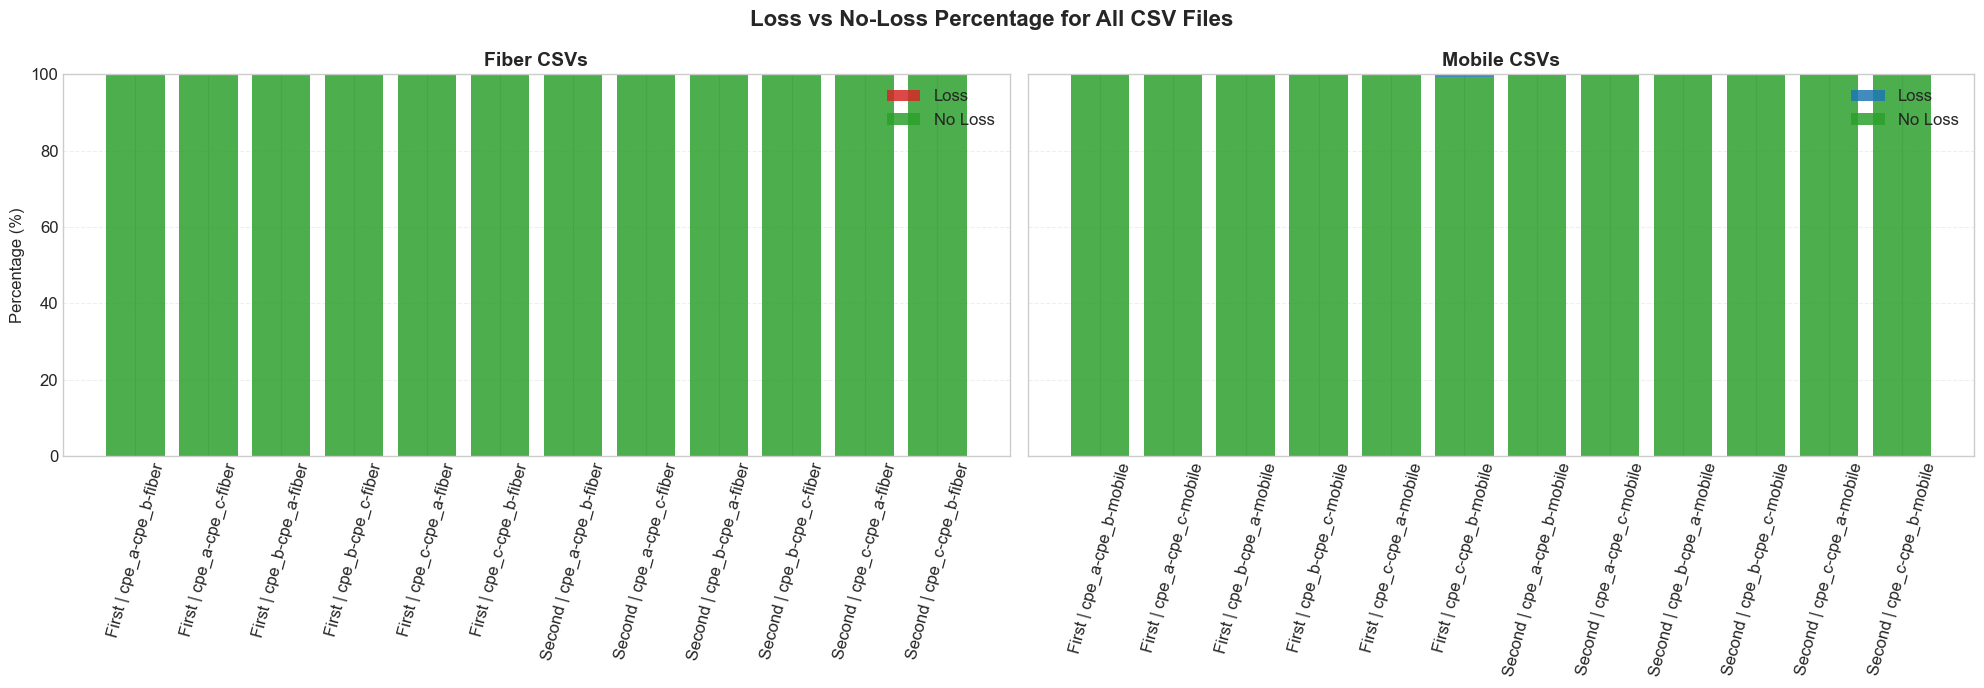

In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

SECOND_WINDOW_DIR = os.path.join(DATASET_DIR, 'second_capture_window')
capture_dirs = {
    'First capture window': FIRST_WINDOW_DIR,
    'Second capture window': SECOND_WINDOW_DIR,
}

summary_rows = []
for window_name, window_dir in capture_dirs.items():
    for csv_name in sorted(os.listdir(window_dir)):
        if not csv_name.endswith('.csv'):
            continue

        csv_path = os.path.join(window_dir, csv_name)
        df = pd.read_csv(csv_path)

        total_rows = len(df)
        loss_rows = int((df['delay_ms'] == -1).sum())
        no_loss_rows = total_rows - loss_rows

        loss_pct = (loss_rows / total_rows) * 100 if total_rows else 0
        no_loss_pct = (no_loss_rows / total_rows) * 100 if total_rows else 0

        summary_rows.append({
            'capture_window': window_name,
            'csv_file': csv_name,
            'total_rows': total_rows,
            'loss_count': loss_rows,
            'no_loss_count': no_loss_rows,
            'loss_fraction': f'{loss_rows}/{total_rows}',
            'no_loss_fraction': f'{no_loss_rows}/{total_rows}',
            'loss_percentage': loss_pct,
            'no_loss_percentage': no_loss_pct,
        })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(['capture_window', 'csv_file']).reset_index(drop=True)

display(summary_df)

print('Overall summary by CSV:')
for _, row in summary_df.iterrows():
    print(
        f"{row['capture_window']} | {row['csv_file']}: ",
        f"Loss {row['loss_count']} ({row['loss_fraction']}, {row['loss_percentage']:.4f}%), ",
        f"No Loss {row['no_loss_count']} ({row['no_loss_fraction']}, {row['no_loss_percentage']:.4f}%)"
    )

plot_df = summary_df.copy()
plot_df['label'] = plot_df['capture_window'].str.replace(' capture window', '', regex=False) + ' | ' + plot_df['csv_file'].str.replace('.csv', '', regex=False)
plot_df['technology'] = plot_df['csv_file'].str.contains('fiber', case=False, regex=False).map({True: 'Fiber', False: 'Mobile'})

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
technologies = [('Fiber', '#d62728'), ('Mobile', '#1f77b4')]

for ax, (tech_name, accent_color) in zip(axes, technologies):
    tech_df = plot_df[plot_df['technology'] == tech_name].copy()
    tech_df = tech_df.sort_values(['capture_window', 'csv_file']).reset_index(drop=True)

    ax.bar(tech_df['label'], tech_df['loss_percentage'], bottom=tech_df['no_loss_percentage'], label='Loss', color=accent_color, alpha=0.85)
    ax.bar(tech_df['label'], tech_df['no_loss_percentage'], label='No Loss', color='#2ca02c', alpha=0.85)


    ax.set_title(f'{tech_name} CSVs', fontsize=14, weight='bold')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=75)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend(loc='upper right')

axes[0].set_ylabel('Percentage (%)')
fig.suptitle('Loss vs No-Loss Percentage for All CSV Files', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('results/raw_data_visualization/all_csv_imbalance_summary.png', dpi=300)
plt.show()

First capture window | cpe_a-cpe_b-fiber.csv: 58 loss out of 57633 rows
First capture window | cpe_a-cpe_b-mobile.csv: 252 loss out of 57633 rows
First capture window | cpe_a-cpe_c-fiber.csv: 58 loss out of 57633 rows
First capture window | cpe_a-cpe_c-mobile.csv: 177 loss out of 57633 rows
First capture window | cpe_b-cpe_a-fiber.csv: 33 loss out of 113441 rows
First capture window | cpe_b-cpe_a-mobile.csv: 251 loss out of 113441 rows
First capture window | cpe_b-cpe_c-fiber.csv: 31 loss out of 113441 rows
First capture window | cpe_b-cpe_c-mobile.csv: 398 loss out of 113441 rows
First capture window | cpe_c-cpe_a-fiber.csv: 5 loss out of 56855 rows
First capture window | cpe_c-cpe_a-mobile.csv: 98 loss out of 56855 rows
First capture window | cpe_c-cpe_b-fiber.csv: 57 loss out of 56855 rows
First capture window | cpe_c-cpe_b-mobile.csv: 310 loss out of 56855 rows

Fiber:
  TOTAL rows: 455858
  TOTAL loss rows: 242 (0.0531%)
  TOTAL no-loss rows: 455616 (99.9469%)

Mobile:
  TOTAL row

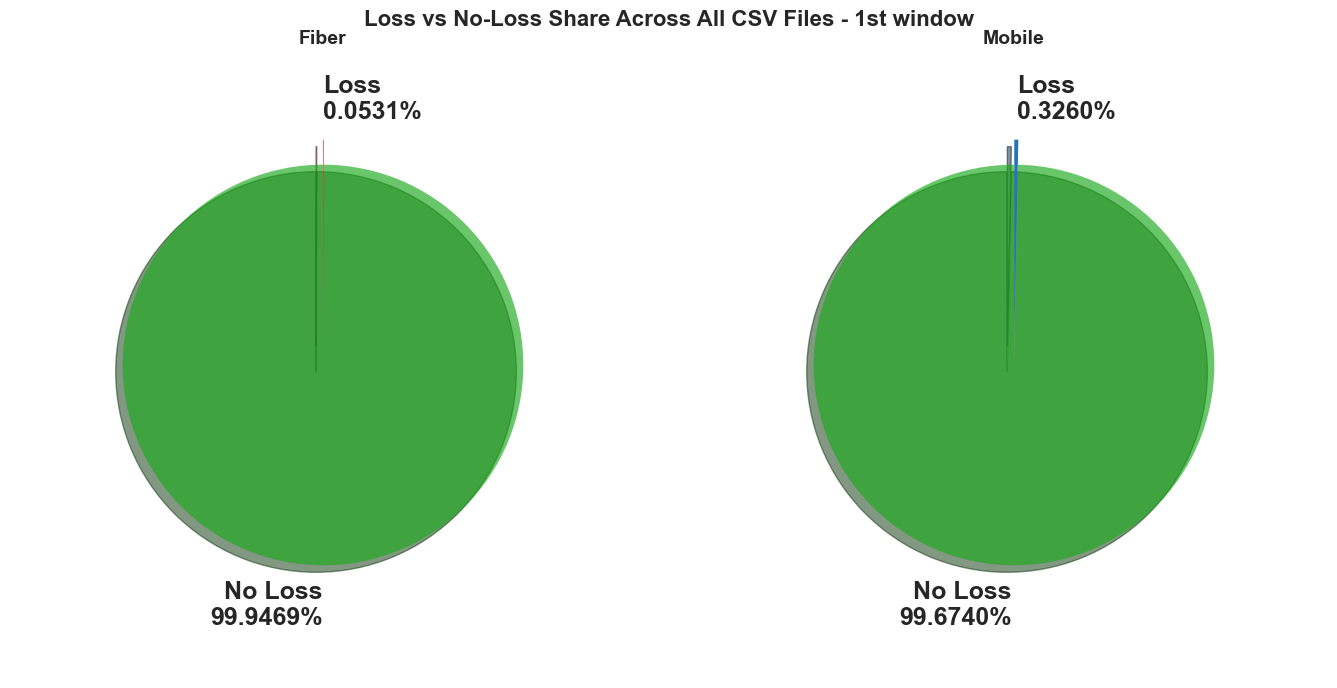

In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt

capture_dirs = {
    'First capture window': os.path.join(DATASET_DIR, 'first_capture_window'),
}

totals = {
    'Fiber': {'rows': 0, 'loss': 0},
    'Mobile': {'rows': 0, 'loss': 0},
}

for window_name, window_dir in capture_dirs.items():
    for csv_name in sorted(os.listdir(window_dir)): 
        if not csv_name.endswith('.csv'):
            continue

        technology = 'Fiber' if 'fiber' in csv_name.lower() else 'Mobile'
        csv_path = os.path.join(window_dir, csv_name)
        df = pd.read_csv(csv_path)
        rows = len(df)
        losses = int((df['delay_ms'] == -1).sum())

        totals[technology]['rows'] += rows
        totals[technology]['loss'] += losses

        print(f'{window_name} | {csv_name}: {losses} loss out of {rows} rows')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
pie_specs = [
    ('Fiber', '#d62728', axes[0]),
    ('Mobile', '#1f77b4', axes[1]),
]

for tech_name, accent_color, ax in pie_specs:
    total_rows = totals[tech_name]['rows']
    total_loss_rows = totals[tech_name]['loss']
    total_no_loss_rows = total_rows - total_loss_rows

    loss_pct = (total_loss_rows / total_rows) * 100 if total_rows else 0
    no_loss_pct = (total_no_loss_rows / total_rows) * 100 if total_rows else 0

    print('')
    print(f'{tech_name}:')
    print(f'  TOTAL rows: {total_rows}')
    print(f'  TOTAL loss rows: {total_loss_rows} ({loss_pct:.4f}%)')
    print(f'  TOTAL no-loss rows: {total_no_loss_rows} ({no_loss_pct:.4f}%)')

    sizes = [total_no_loss_rows, total_loss_rows]
    labels = [f'No Loss\n{no_loss_pct:.4f}%', f'Loss\n{loss_pct:.4f}%']
    colors = ["#1ca91ca7", accent_color]
    explode = (0, 0.10)

    ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        explode=explode,
        startangle=90,
        shadow=True,
        textprops={'fontsize': 18, 'weight': 'bold'},
        radius=0.8,         # Torta più piccola
        labeldistance=1.2   # Etichette più lontane dal centro
    )

    ax.set_title(f'{tech_name}', fontsize=14, weight='bold')

fig.suptitle('Loss vs No-Loss Share Across All CSV Files - 1st window', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('results/raw_data_visualization/global_loss_pie_chart_fiber_mobile_1stwin.png', dpi=300)
plt.show()

Second capture window | cpe_a-cpe_b-fiber.csv: 3 loss out of 117252 rows
Second capture window | cpe_a-cpe_b-mobile.csv: 491 loss out of 117252 rows
Second capture window | cpe_a-cpe_c-fiber.csv: 5 loss out of 117252 rows
Second capture window | cpe_a-cpe_c-mobile.csv: 439 loss out of 117250 rows
Second capture window | cpe_b-cpe_a-fiber.csv: 1 loss out of 234502 rows
Second capture window | cpe_b-cpe_a-mobile.csv: 1008 loss out of 234502 rows
Second capture window | cpe_b-cpe_c-fiber.csv: 12 loss out of 234502 rows
Second capture window | cpe_b-cpe_c-mobile.csv: 182 loss out of 234502 rows
Second capture window | cpe_c-cpe_a-fiber.csv: 2 loss out of 117252 rows
Second capture window | cpe_c-cpe_a-mobile.csv: 447 loss out of 117252 rows
Second capture window | cpe_c-cpe_b-fiber.csv: 5 loss out of 117252 rows
Second capture window | cpe_c-cpe_b-mobile.csv: 88 loss out of 117252 rows

Fiber:
  TOTAL rows: 938012
  TOTAL loss rows: 28 (0.0030%)
  TOTAL no-loss rows: 937984 (99.9970%)

Mob

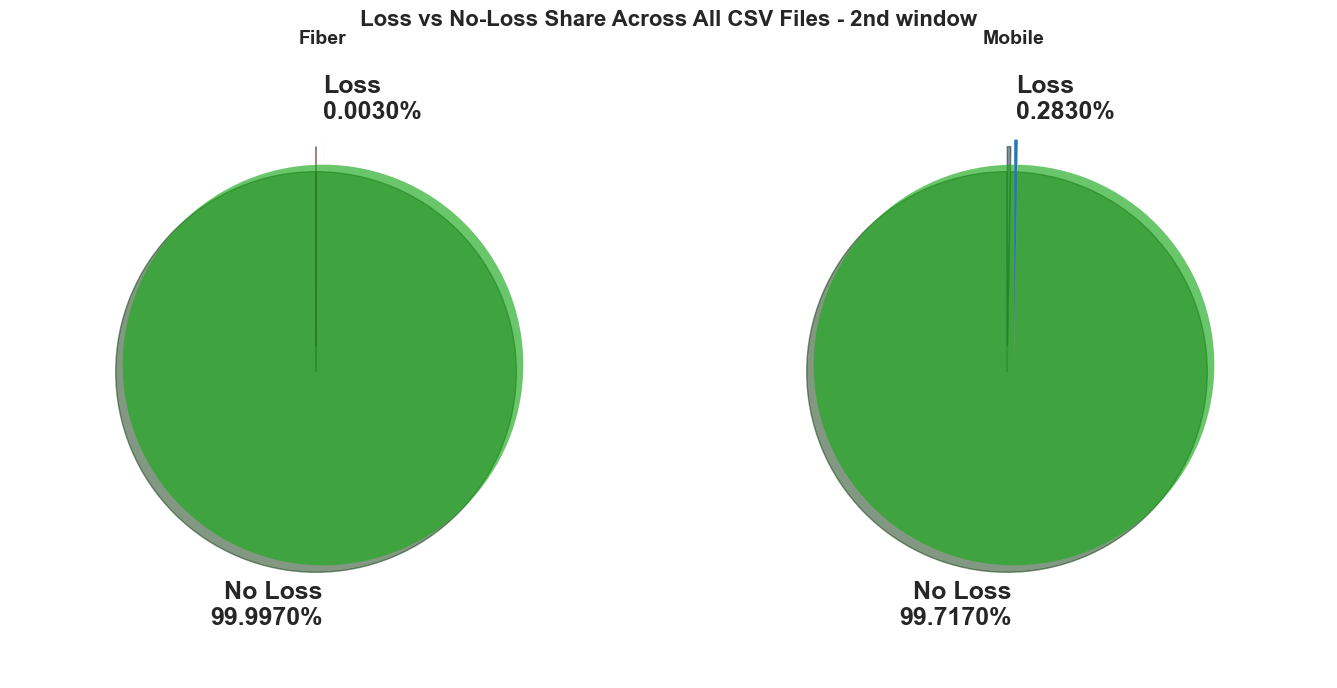

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

capture_dirs = {
    'Second capture window': os.path.join(DATASET_DIR, 'second_capture_window'),
}

totals = {
    'Fiber': {'rows': 0, 'loss': 0},
    'Mobile': {'rows': 0, 'loss': 0},
}

for window_name, window_dir in capture_dirs.items():
    for csv_name in sorted(os.listdir(window_dir)): 
        if not csv_name.endswith('.csv'):
            continue

        technology = 'Fiber' if 'fiber' in csv_name.lower() else 'Mobile'
        csv_path = os.path.join(window_dir, csv_name)
        df = pd.read_csv(csv_path)
        rows = len(df)
        losses = int((df['delay_ms'] == -1).sum())

        totals[technology]['rows'] += rows
        totals[technology]['loss'] += losses

        print(f'{window_name} | {csv_name}: {losses} loss out of {rows} rows')

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
pie_specs = [
    ('Fiber', '#d62728', axes[0]),
    ('Mobile', '#1f77b4', axes[1]),
]

for tech_name, accent_color, ax in pie_specs:
    total_rows = totals[tech_name]['rows']
    total_loss_rows = totals[tech_name]['loss']
    total_no_loss_rows = total_rows - total_loss_rows

    loss_pct = (total_loss_rows / total_rows) * 100 if total_rows else 0
    no_loss_pct = (total_no_loss_rows / total_rows) * 100 if total_rows else 0

    print('')
    print(f'{tech_name}:')
    print(f'  TOTAL rows: {total_rows}')
    print(f'  TOTAL loss rows: {total_loss_rows} ({loss_pct:.4f}%)')
    print(f'  TOTAL no-loss rows: {total_no_loss_rows} ({no_loss_pct:.4f}%)')

    sizes = [total_no_loss_rows, total_loss_rows]
    labels = [f'No Loss\n{no_loss_pct:.4f}%', f'Loss\n{loss_pct:.4f}%']
    colors = ["#1ca91ca7", accent_color]
    explode = (0, 0.10)

    ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        explode=explode,
        startangle=90,
        shadow=True,
        textprops={'fontsize': 18, 'weight': 'bold'},
        radius=0.8,         # Torta più piccola
        labeldistance=1.2   # Etichette più lontane dal centro
    )

    ax.set_title(f'{tech_name}', fontsize=14, weight='bold')

fig.suptitle('Loss vs No-Loss Share Across All CSV Files - 2nd window', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('results/raw_data_visualization/global_loss_pie_chart_fiber_mobile_2ndwin.png', dpi=300)
plt.show()

## 4. Correlation between Delay and Packet Loss (Dataset Visualized)
This section shows the correlation between packet loss rate and delay increase, similar to the dataset visualization slide in the project description. The left y-axis represents the delay in milliseconds (using a log scale to visualize both fiber and 4G), and the right y-axis represents the packet loss percentage (using a 10-minute rolling average).

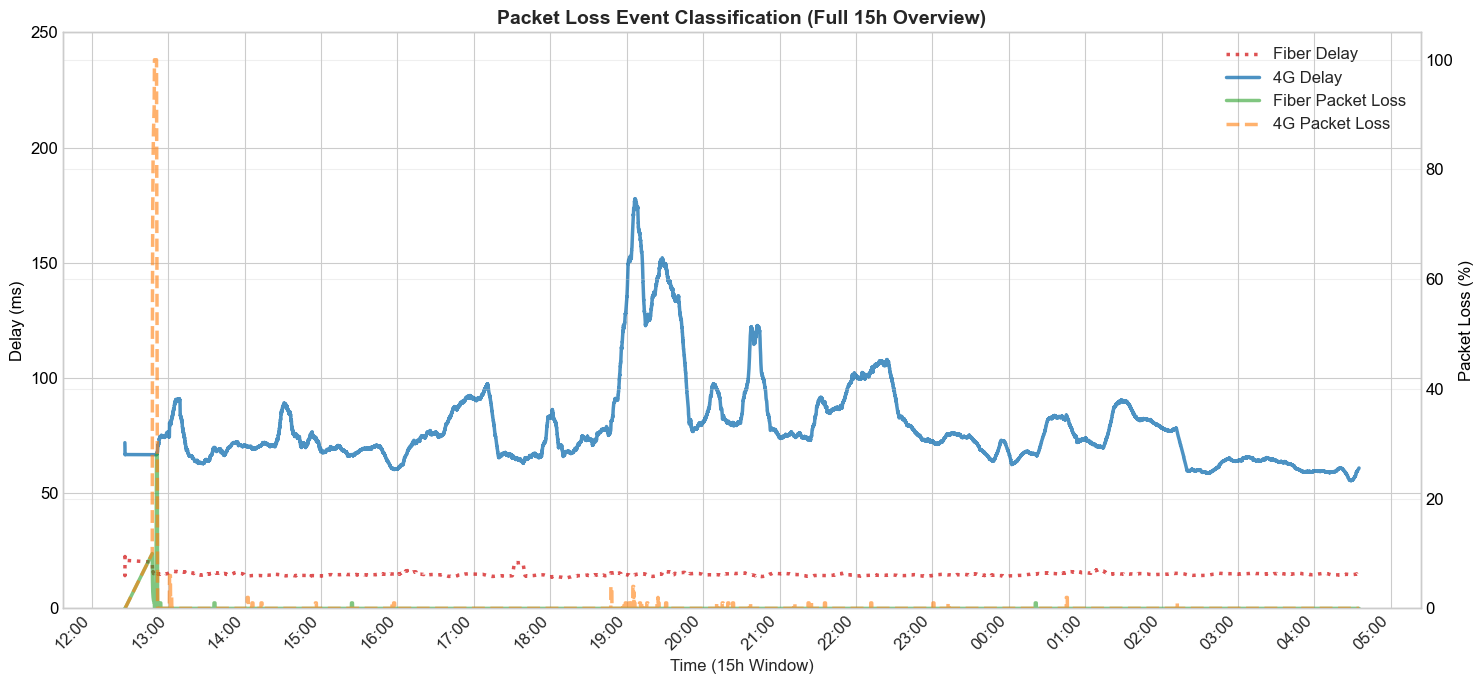

<Figure size 1200x600 with 0 Axes>

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- PREPARAZIONE DATI ---
df_fiber['time'] = pd.to_datetime(df_fiber['time'])
df_mobile['time'] = pd.to_datetime(df_mobile['time'])

# Finestre di smoothing (in secondi, assumendo 1 riga = 1 secondo)
# Su 15 ore (54.000 secondi), finestre da 10 minuti (600) e 1 minuto (60) vanno benissimo
SMOOTHING_WINDOW_LOSS = 100
SMOOTHING_WINDOW_DELAY = 1000 

# Prepare Fiber data
df_fiber_clean = df_fiber.copy()
df_fiber_clean['pkt_loss'] = (df_fiber_clean['delay_ms'] == -1).astype(float)
df_fiber_clean['rolling_loss_pct'] = df_fiber_clean['pkt_loss'].rolling(window=SMOOTHING_WINDOW_LOSS, min_periods=1).mean() * 100
df_fiber_clean['clean_delay'] = df_fiber_clean['delay_ms'].replace(-1, np.nan).ffill()
df_fiber_clean['smooth_delay'] = df_fiber_clean['clean_delay'].rolling(window=SMOOTHING_WINDOW_DELAY, min_periods=1).mean()

# Prepare Mobile data
df_mobile_clean = df_mobile.copy()
df_mobile_clean['pkt_loss'] = (df_mobile_clean['delay_ms'] == -1).astype(float)
df_mobile_clean['rolling_loss_pct'] = df_mobile_clean['pkt_loss'].rolling(window=SMOOTHING_WINDOW_LOSS, min_periods=1).mean() * 100
df_mobile_clean['clean_delay'] = df_mobile_clean['delay_ms'].replace(-1, np.nan).ffill()
df_mobile_clean['smooth_delay'] = df_mobile_clean['clean_delay'].rolling(window=SMOOTHING_WINDOW_DELAY, min_periods=1).mean()


# --- PLOTTING ---
fig, ax1 = plt.subplots(figsize=(15, 7))

# Asse Sinistro (Delay) - Scala Lineare
line1 = ax1.plot(df_fiber_clean['time'], df_fiber_clean['smooth_delay'], label='Fiber Delay', color='#d62728', linestyle=':', alpha=0.8, linewidth=2.5)
line2 = ax1.plot(df_mobile_clean['time'], df_mobile_clean['smooth_delay'], label='4G Delay', color='#1f77b4', alpha=0.8, linewidth=2.5)

ax1.set_xlabel('Time (15h Window)')
ax1.set_ylabel('Delay (ms)', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_ylim(0, 250) 

# Asse Destro (Packet Loss)
ax2 = ax1.twinx()
line3 = ax2.plot(df_fiber_clean['time'], df_fiber_clean['rolling_loss_pct'], label='Fiber Packet Loss', color='#2ca02c', linestyle='-', alpha=0.6, linewidth=2.5)
line4 = ax2.plot(df_mobile_clean['time'], df_mobile_clean['rolling_loss_pct'], label='4G Packet Loss', color='#ff7f0e', linestyle='--', alpha=0.6, linewidth=2.5)

ax2.set_ylabel('Packet Loss (%)', color='black')
ax2.tick_params(axis='y', labelcolor='black')
# Non fisso l'ylim superiore qui per permettere ad ax2 di scalare automaticamente su tutto il % pkt loss delle 15 ore
ax2.set_ylim(bottom=-0.01) 

# --- FORMATTAZIONE ASSE X (LE 15 ORE) ---
# Formatta l'asse x per mostrare le ore in modo leggibile ("HH:MM")
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
# Mette una "tick" (tacca) sull'asse X ogni ora per coprire bene le 15 ore
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1)) 
# Ruota le etichette per evitare che si sovrappongano
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# Gestione Legenda
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', shadow=True)

plt.title('Packet Loss Event Classification (Full 15h Overview)', fontsize=14, weight='bold')
plt.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
plt.savefig('results/raw_data_visualization/packet_loss_classification_full_15h.png', dpi=300)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_network_data(df_fiber, df_mobile, start_time, end_time, smoothing_window_loss, smoothing_window_delay, save_path=None):
    """
    Genera un grafico che confronta il ritardo e la perdita di pacchetti tra Fiber e 4G 
    all'interno di una specifica finestra temporale.
    """
    
    # 1. Assicuriamoci che le colonne 'time' siano datetime (se non lo sono già)
    df_fiber['time'] = pd.to_datetime(df_fiber['time'])
    df_mobile['time'] = pd.to_datetime(df_mobile['time'])
    
    # Converte gli input di tempo in oggetti datetime per il filtraggio
    start_time = pd.to_datetime(start_time)
    end_time = pd.to_datetime(end_time)
    
    # 2. Filtra i dataframe in base alla finestra temporale richiesta
    mask_fiber = (df_fiber['time'] >= start_time) & (df_fiber['time'] <= end_time)
    df_fiber_filtered = df_fiber.loc[mask_fiber].copy()
    
    mask_mobile = (df_mobile['time'] >= start_time) & (df_mobile['time'] <= end_time)
    df_mobile_filtered = df_mobile.loc[mask_mobile].copy()

    # Se i dataframe filtrati sono vuoti, avvisa e ferma la funzione
    if df_fiber_filtered.empty or df_mobile_filtered.empty:
        print("Attenzione: Nessun dato trovato per l'intervallo di tempo specificato.")
        return

    # 3. Prepare Fiber data
    df_fiber_filtered['pkt_loss'] = (df_fiber_filtered['delay_ms'] == -1).astype(float)
    df_fiber_filtered['rolling_loss_pct'] = df_fiber_filtered['pkt_loss'].rolling(window=smoothing_window_loss, min_periods=1).mean() * 100
    df_fiber_filtered['clean_delay'] = df_fiber_filtered['delay_ms'].replace(-1, np.nan).ffill()
    df_fiber_filtered['smooth_delay'] = df_fiber_filtered['clean_delay'].rolling(window=smoothing_window_delay, min_periods=1).mean()

    # 4. Prepare Mobile data
    df_mobile_filtered['pkt_loss'] = (df_mobile_filtered['delay_ms'] == -1).astype(float)
    df_mobile_filtered['rolling_loss_pct'] = df_mobile_filtered['pkt_loss'].rolling(window=smoothing_window_loss, min_periods=1).mean() * 100
    df_mobile_filtered['clean_delay'] = df_mobile_filtered['delay_ms'].replace(-1, np.nan).ffill()
    df_mobile_filtered['smooth_delay'] = df_mobile_filtered['clean_delay'].rolling(window=smoothing_window_delay, min_periods=1).mean()

    # --- PLOTTING ---
    fig, ax1 = plt.subplots(figsize=(15, 7))

    # Asse Sinistro (Delay)
    line1 = ax1.plot(df_fiber_filtered['time'], df_fiber_filtered['smooth_delay'], label='Fiber Delay', color='#d62728', linestyle=':', alpha=0.8, linewidth=2.5)
    line2 = ax1.plot(df_mobile_filtered['time'], df_mobile_filtered['smooth_delay'], label='4G Delay', color='#1f77b4', alpha=0.8, linewidth=2.5)

    ax1.set_xlabel('Time')
    ax1.set_ylabel('Delay (ms)', color='black')
    ax1.tick_params(axis='y', labelcolor='black')
    ax1.set_ylim(0, 250) 

    # Asse Destro (Packet Loss)
    ax2 = ax1.twinx()
    line3 = ax2.plot(df_fiber_filtered['time'], df_fiber_filtered['rolling_loss_pct'], label='Fiber Packet Loss', color='#2ca02c', linestyle='-', alpha=0.6, linewidth=2.5)
    line4 = ax2.plot(df_mobile_filtered['time'], df_mobile_filtered['rolling_loss_pct'], label='4G Packet Loss', color='#ff7f0e', linestyle='--', alpha=0.6, linewidth=2.5)

    ax2.set_ylabel('Packet Loss (%)', color='black')
    ax2.tick_params(axis='y', labelcolor='black')
    ax2.set_ylim(bottom=-0.01) 

    # --- FORMATTAZIONE ASSE X DINAMICA ---
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    # AutoDateLocator sceglie automaticamente la spaziatura migliore per i tick in base allo zoom
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator()) 
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Gestione Legenda
    lines = line1 + line2 + line3 + line4
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', shadow=True)

    plt.title(f'Packet Loss Event Classification ({start_time} to {end_time})', fontsize=14, weight='bold')
    plt.grid(True, alpha=0.3)
    fig.tight_layout()

    # Gestione Salvataggio
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"Grafico salvato in: {save_path}")
        
    plt.show()


Grafico salvato in: results/raw_data_visualization/packet_loss_custom_window_1.png


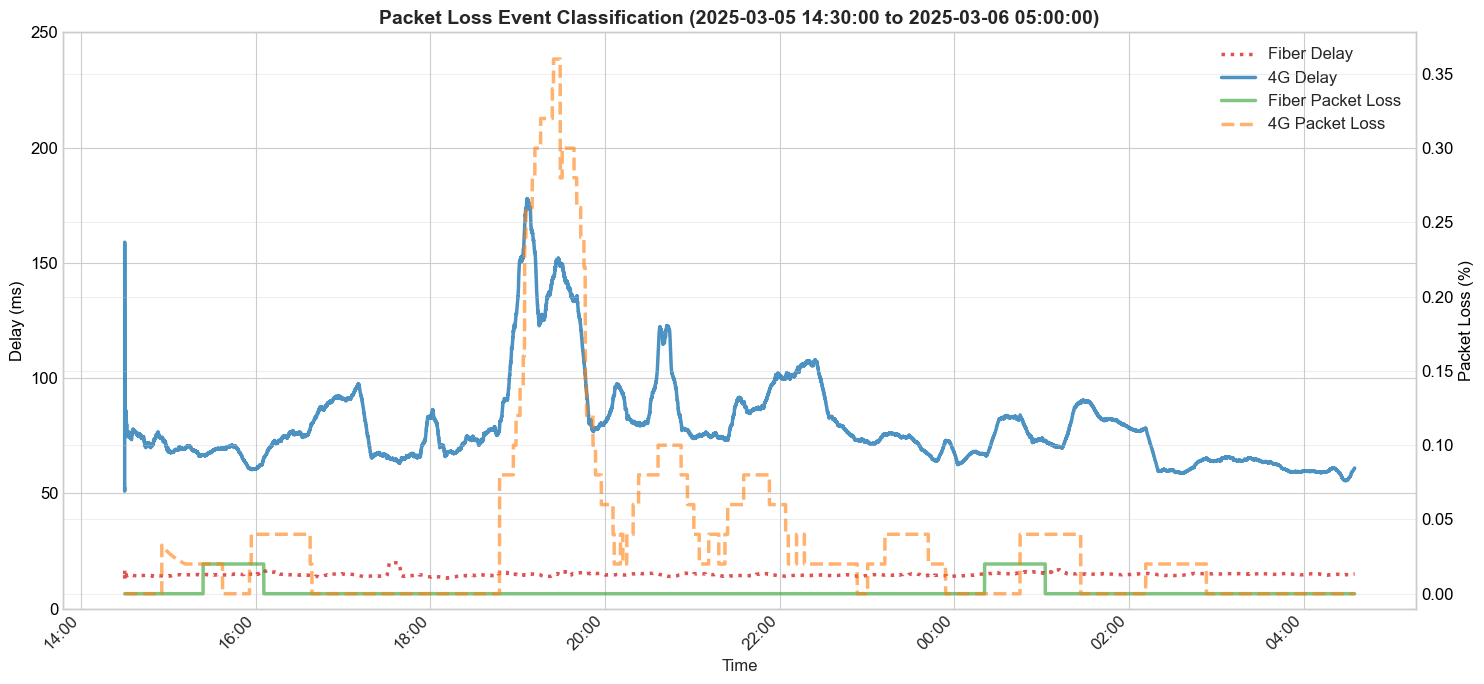

In [35]:
# --- ESEMPIO DI UTILIZZO DELLA FUNZIONE ---
# Sostituisci le stringhe di tempo con quelle reali presenti nel tuo dataset

plot_network_data(
    df_fiber=df_fiber, 
    df_mobile=df_mobile, 
    start_time='2025-03-05 14:30:00',  # Sostituisci con il tuo orario di inizio
    end_time='2025-03-06 05:00:00',    # Sostituisci con il tuo orario di fine
    smoothing_window_loss=5000, 
    smoothing_window_delay=1000,
    save_path='results/raw_data_visualization/packet_loss_custom_window_1.png'
)

Grafico salvato in: results/raw_data_visualization/packet_loss_custom_window.png


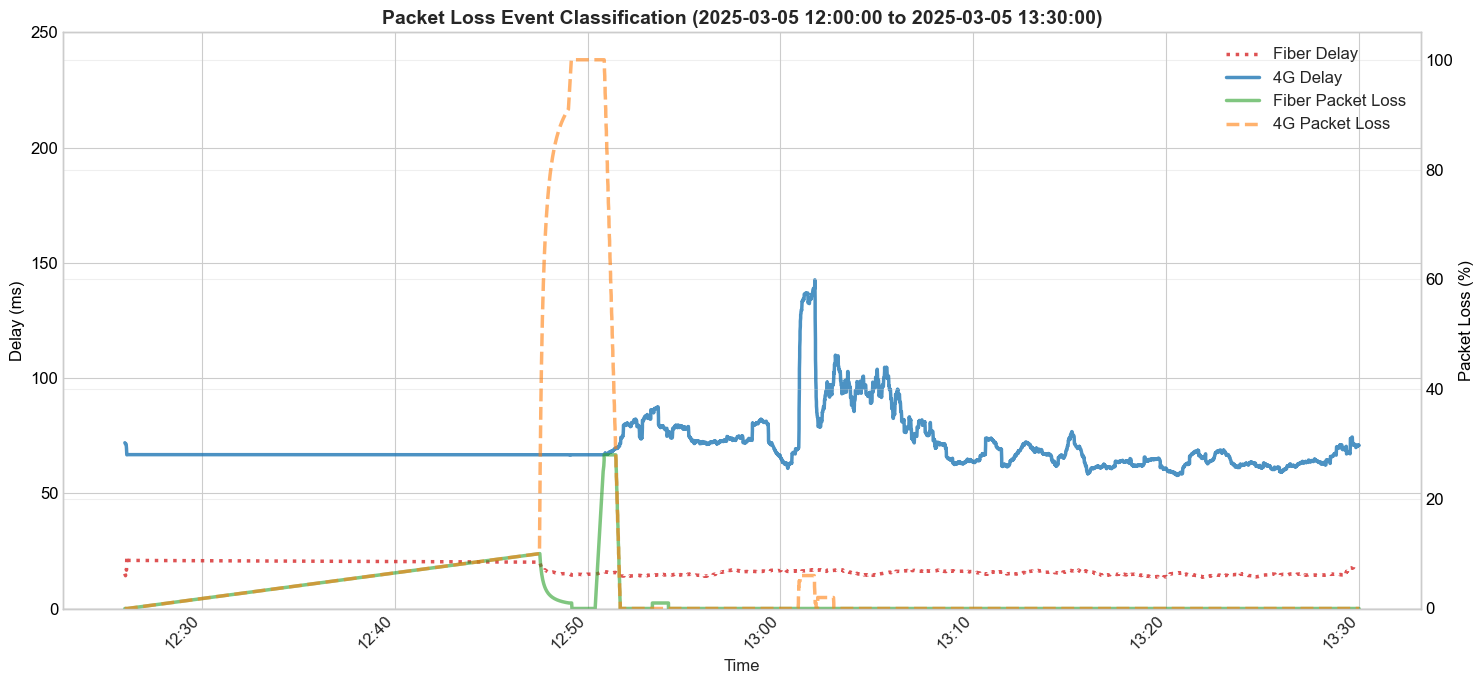

In [23]:
plot_network_data(
    df_fiber=df_fiber, 
    df_mobile=df_mobile, 
    start_time='2025-03-05 12:00:00',  # Sostituisci con il tuo orario di inizio
    end_time='2025-03-05 13:30:00',    # Sostituisci con il tuo orario di fine
    smoothing_window_loss=100, 
    smoothing_window_delay=100,
    save_path='results/raw_data_visualization/packet_loss_custom_window.png'
)

Grafico salvato in: results/raw_data_visualization/packet_loss_custom_window.png


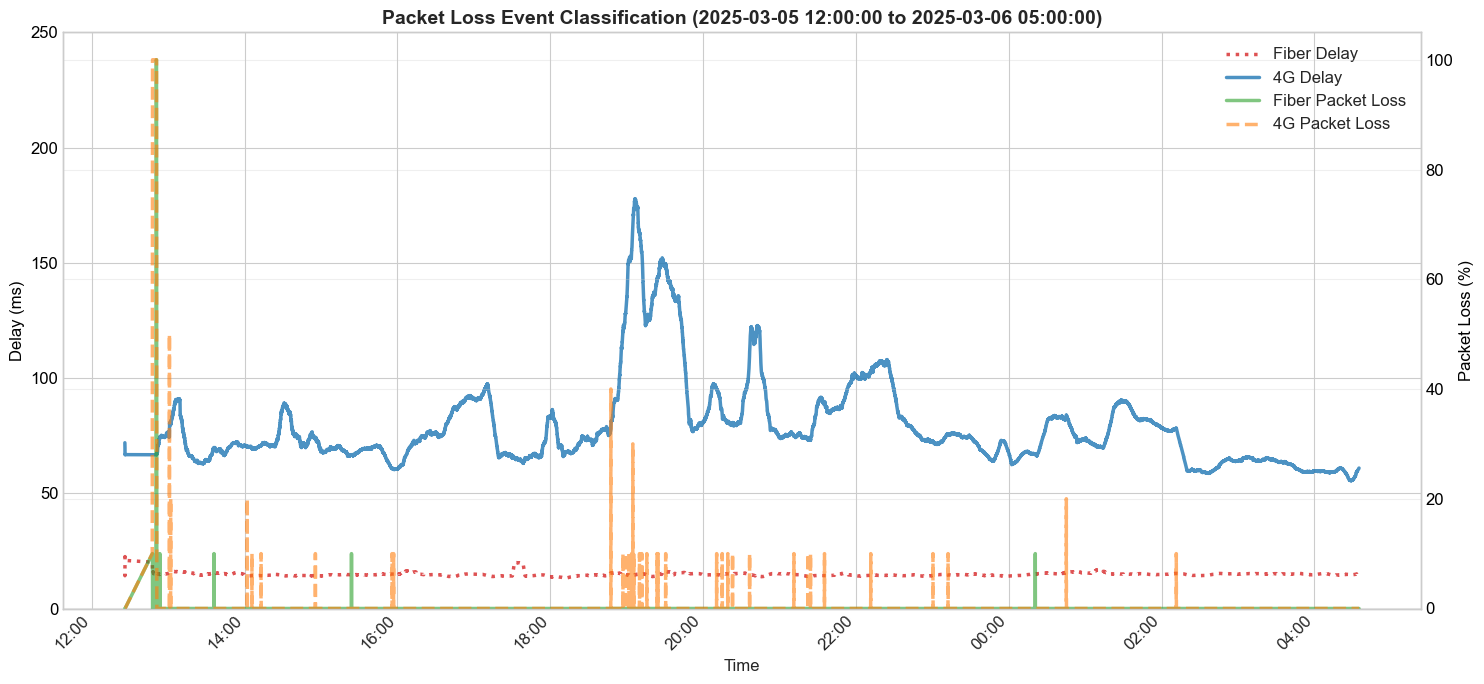

In [24]:
plot_network_data(
    df_fiber=df_fiber, 
    df_mobile=df_mobile, 
    start_time='2025-03-05 12:00:00',  # Sostituisci con il tuo orario di inizio
    end_time='2025-03-06 05:00:00',    # Sostituisci con il tuo orario di fine
    smoothing_window_loss=10, 
    smoothing_window_delay=1000,
    save_path='results/raw_data_visualization/packet_loss_custom_window.png'
)

## 5. Feature Utility Visualization for Modeling
In this section we visualize the additional candidate features requested in the project plan:
- Trend / Slope (linear regression coefficient on recent delay window)
- Rate of delay changes and recent delta
- Historical packet loss counts

To evaluate whether they may be useful for prediction, we compare each feature against a forward-looking label (`future_pkt_loss`), which is `1` when at least one packet loss event appears in the next time window.

In [25]:
from pandas.api.indexers import FixedForwardWindowIndexer

# Feature configuration (you can tune these values)
FEATURE_LOOKBACK = 60      # seconds used to compute trend/rate/history features
RECENT_DELTA_H = 5         # seconds for short-term delay delta
FUTURE_WINDOW = 20         # seconds used to define future packet-loss label


def build_feature_frame(df, tech_name, lookback=60, recent_delta_h=5, future_window=20):
    data = df.copy().sort_values('time').reset_index(drop=True)
    data['time'] = pd.to_datetime(data['time'])

    # Packet loss indicator and cleaned delay series
    data['pkt_loss'] = (data['delay_ms'] == -1).astype(int)
    data['clean_delay'] = data['delay_ms'].replace(-1, np.nan).ffill().bfill()

    # Trend/Slope using linear regression coefficient over a rolling window
    x = np.arange(lookback, dtype=float)
    x_sum = x.sum()
    x2_sum = (x ** 2).sum()
    denom = lookback * x2_sum - x_sum ** 2

    def rolling_slope(y):
        y = np.asarray(y, dtype=float)
        return (lookback * np.sum(x * y) - x_sum * np.sum(y)) / denom

    data['trend_slope'] = data['clean_delay'].rolling(
        window=lookback,
        min_periods=lookback
    ).apply(rolling_slope, raw=True)

    # Rate of delay changes (average absolute variation in the last lookback seconds)
    data['delay_change_rate'] = data['clean_delay'].diff().abs().rolling(
        window=lookback,
        min_periods=1
    ).mean()

    # Recent delay delta (difference against a short recent horizon)
    data['recent_delta'] = data['clean_delay'].diff(periods=recent_delta_h)

    # Historical packet loss counts in the last lookback seconds
    data['hist_loss_count'] = data['pkt_loss'].rolling(window=lookback, min_periods=1).sum()

    # Forward-looking target: any packet loss in the next FUTURE_WINDOW seconds
    indexer = FixedForwardWindowIndexer(window_size=future_window)
    future_series = data['pkt_loss'].shift(-1).rolling(indexer, min_periods=1).max()
    data['future_pkt_loss'] = future_series.fillna(0).astype(int)

    data['technology'] = tech_name

    return data[[
        'time',
        'technology',
        'trend_slope',
        'delay_change_rate',
        'recent_delta',
        'hist_loss_count',
        'future_pkt_loss'
    ]]


fiber_features = build_feature_frame(
    df_fiber,
    tech_name='Fiber',
    lookback=FEATURE_LOOKBACK,
    recent_delta_h=RECENT_DELTA_H,
    future_window=FUTURE_WINDOW
)

mobile_features = build_feature_frame(
    df_mobile,
    tech_name='4G',
    lookback=FEATURE_LOOKBACK,
    recent_delta_h=RECENT_DELTA_H,
    future_window=FUTURE_WINDOW
)

feature_df = pd.concat([fiber_features, mobile_features], ignore_index=True)

print('Feature frame created:')
print(feature_df.head())

print('\nCorrelation with future packet-loss label (rough linear indicator):')
for tech, frame in [('Fiber', fiber_features), ('4G', mobile_features)]:
    subset = frame[['trend_slope', 'delay_change_rate', 'recent_delta', 'hist_loss_count', 'future_pkt_loss']].dropna()
    corr = subset.corr(numeric_only=True)['future_pkt_loss'].drop('future_pkt_loss')
    print(f'\n{tech}:')
    print(corr)


Feature frame created:
                     time technology  trend_slope  delay_change_rate  \
0 2025-03-05 12:26:00.749      Fiber          NaN                NaN   
1 2025-03-05 12:26:01.749      Fiber          NaN           0.781800   
2 2025-03-05 12:26:02.750      Fiber          NaN           0.940200   
3 2025-03-05 12:26:03.750      Fiber          NaN           2.344000   
4 2025-03-05 12:26:04.759      Fiber          NaN           3.411575   

   recent_delta  hist_loss_count  future_pkt_loss  
0           NaN              0.0                1  
1           NaN              0.0                1  
2           NaN              0.0                1  
3           NaN              0.0                1  
4           NaN              0.0                1  

Correlation with future packet-loss label (rough linear indicator):

Fiber:
trend_slope          0.010152
delay_change_rate    0.000066
recent_delta         0.001157
hist_loss_count      0.166951
Name: future_pkt_loss, dtype: float

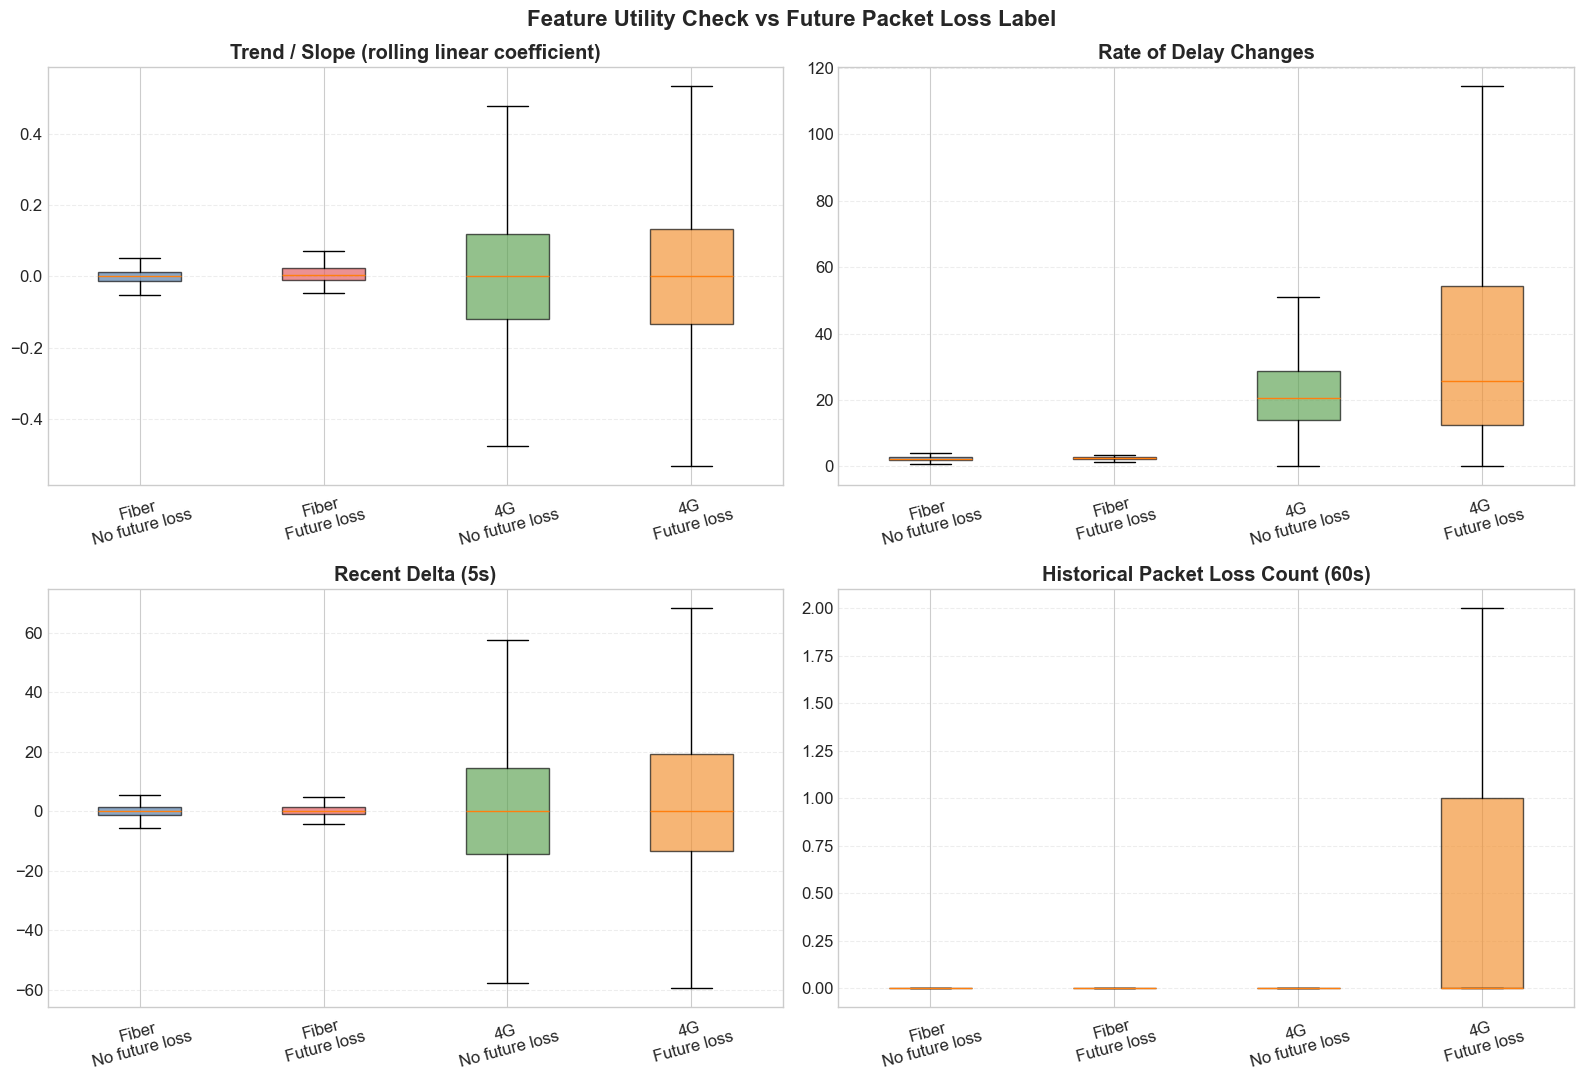

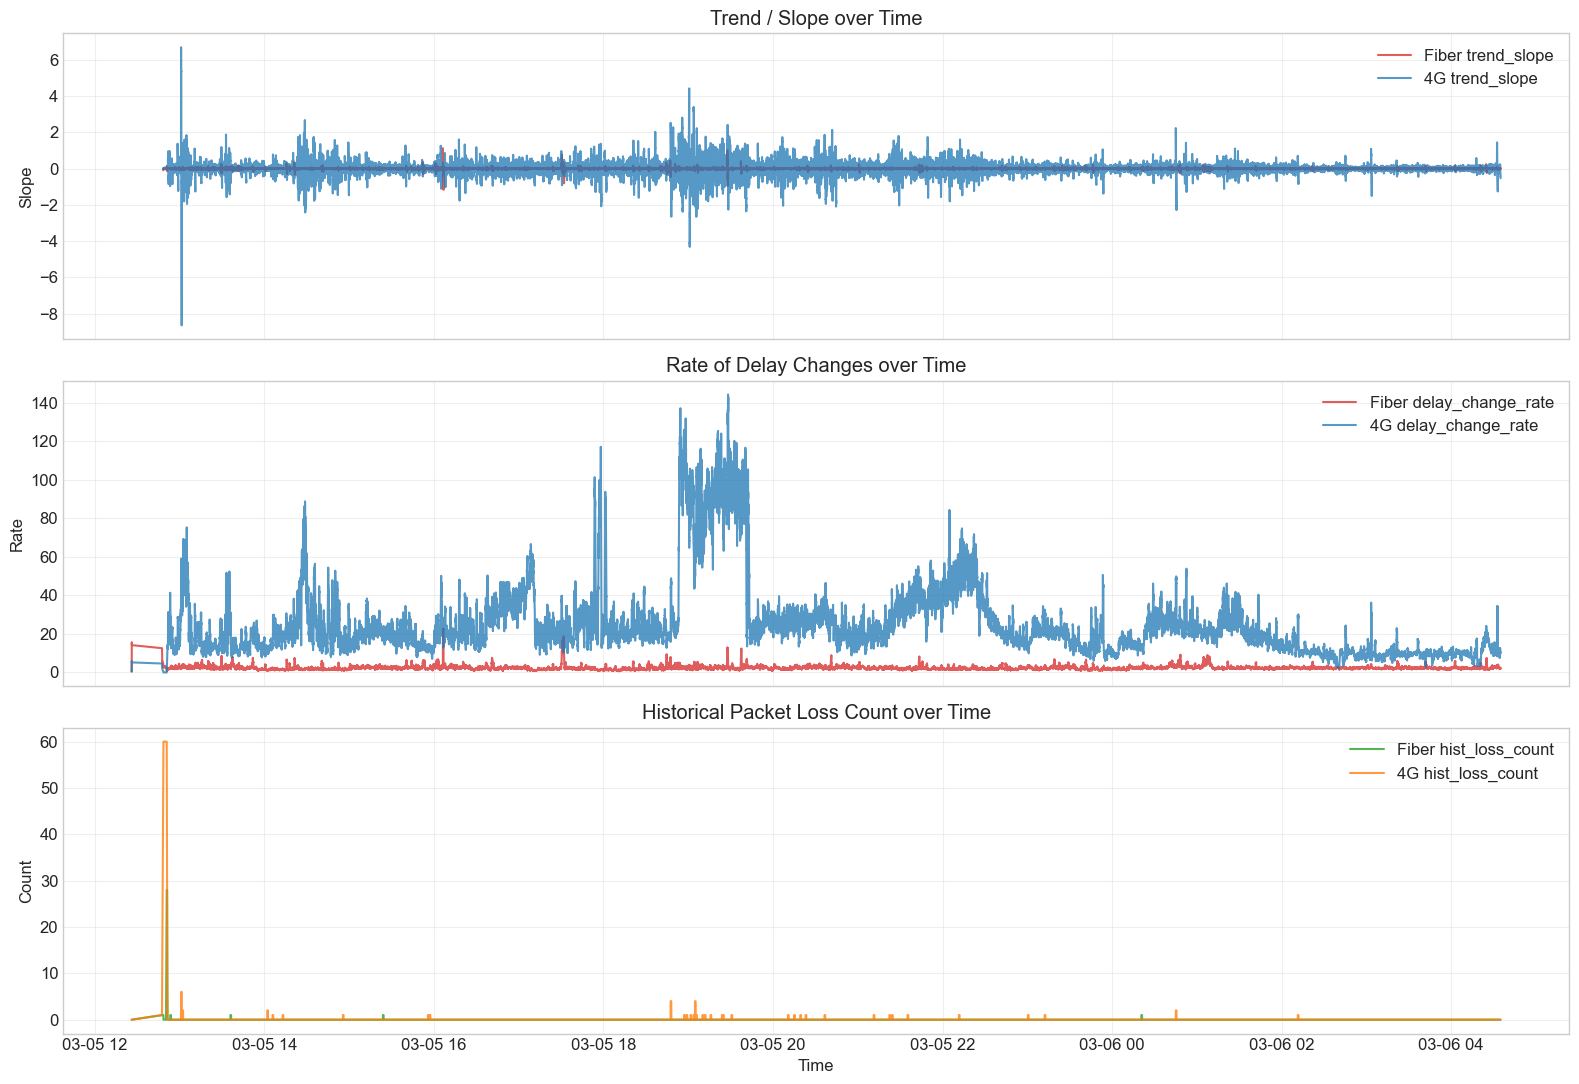

In [26]:
# Visualization: feature distributions conditioned on future packet loss
features_to_plot = [
    ('trend_slope', 'Trend / Slope (rolling linear coefficient)'),
    ('delay_change_rate', 'Rate of Delay Changes'),
    ('recent_delta', f'Recent Delta ({RECENT_DELTA_H}s)'),
    ('hist_loss_count', f'Historical Packet Loss Count ({FEATURE_LOOKBACK}s)')
]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.flatten()

for ax, (feature_col, title) in zip(axes, features_to_plot):
    data_groups = []
    labels = []

    for tech_name, frame in [('Fiber', fiber_features), ('4G', mobile_features)]:
        no_future_loss = frame.loc[frame['future_pkt_loss'] == 0, feature_col].dropna()
        yes_future_loss = frame.loc[frame['future_pkt_loss'] == 1, feature_col].dropna()

        data_groups.extend([no_future_loss, yes_future_loss])
        labels.extend([
            f'{tech_name}\nNo future loss',
            f'{tech_name}\nFuture loss'
        ])

    box = ax.boxplot(data_groups, tick_labels=labels, showfliers=False, patch_artist=True)

    colors = ['#4e79a7', '#e15759', '#59a14f', '#f28e2b']
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)

    ax.set_title(title, weight='bold')
    ax.grid(True, axis='y', linestyle='--', alpha=0.35)
    ax.tick_params(axis='x', labelrotation=15)

plt.suptitle('Feature Utility Check vs Future Packet Loss Label', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig('results/raw_data_visualization/feature_utility_boxplots.png', dpi=300)
plt.show()


# Optional time-series view for intuition on temporal dynamics
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

axes[0].plot(fiber_features['time'], fiber_features['trend_slope'], label='Fiber trend_slope', color='#d62728', alpha=0.75)
axes[0].plot(mobile_features['time'], mobile_features['trend_slope'], label='4G trend_slope', color='#1f77b4', alpha=0.75)
axes[0].set_ylabel('Slope')
axes[0].set_title('Trend / Slope over Time')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(fiber_features['time'], fiber_features['delay_change_rate'], label='Fiber delay_change_rate', color='#d62728', alpha=0.75)
axes[1].plot(mobile_features['time'], mobile_features['delay_change_rate'], label='4G delay_change_rate', color='#1f77b4', alpha=0.75)
axes[1].set_ylabel('Rate')
axes[1].set_title('Rate of Delay Changes over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(fiber_features['time'], fiber_features['hist_loss_count'], label='Fiber hist_loss_count', color='#2ca02c', alpha=0.8)
axes[2].plot(mobile_features['time'], mobile_features['hist_loss_count'], label='4G hist_loss_count', color='#ff7f0e', alpha=0.8)
axes[2].set_ylabel('Count')
axes[2].set_title('Historical Packet Loss Count over Time')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.xlabel('Time')
plt.tight_layout()
plt.savefig('results/raw_data_visualization/feature_utility_timeseries.png', dpi=300)
plt.show()


    -> Processing file 1/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 840.82 ms
    -> Processing file 2/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 487.51 ms
    -> Processing file 3/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 646.33 ms
    -> Processing file 4/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 856.74 ms
    -> Processing file 5/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 836.31 ms
    -> Processing file 6/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 791.03 ms
    -> Processing file 7/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 457.76 ms
    -> Processing file 8/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 452.10 ms
    -> Processing file 9/16 with 23450 original rows...
       M

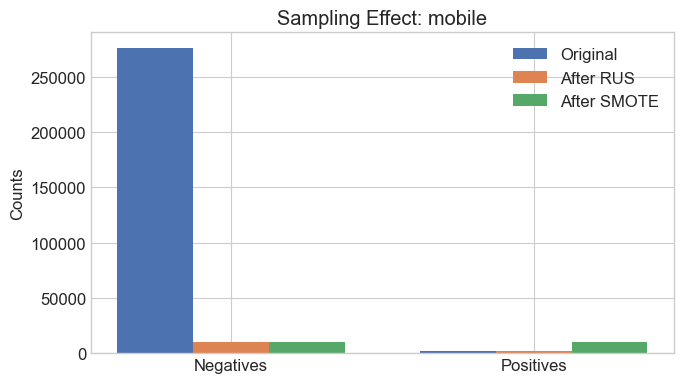

    -> Processing file 1/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 840.82 ms
    -> Processing file 2/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 487.51 ms
    -> Processing file 3/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 646.33 ms
    -> Processing file 4/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 856.74 ms
    -> Processing file 5/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 836.31 ms
    -> Processing file 6/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 791.03 ms
    -> Processing file 7/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 457.76 ms
    -> Processing file 8/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 452.10 ms
    -> Processing file 9/16 with 23450 original rows...
       M

c:\Users\Pietro Guidetti\Documents\Portables\conda_installation\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:39:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[FeatureImp] Saved: results/raw_data_visualization\feature_importance_mobile.png


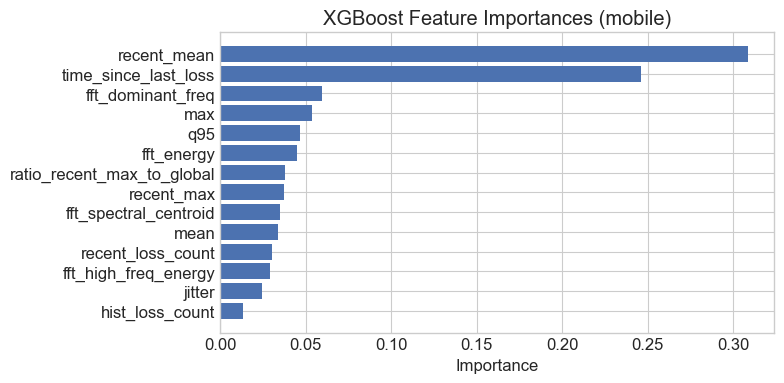

In [37]:
# --- Sampling Effect Visualization (consistent with main_comparison_LSTM pipeline)
import sys
import os
import importlib

# modules names cannot start with a number, so we use importlib to load the main_comparison_LSTM module
module_02 = importlib.import_module("02_main_comparison_LSTM")
process_dataset_all = module_02.process_dataset_all

sys.path.append(os.getcwd())
from src.data_loader import load_config, load_and_split_data

from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

# Load experiment config used by main script
cfg_path = 'config/exp1.yaml'
config = load_config(cfg_path)
N = int(config.get('N', 15))
X = int(config.get('X', 10))
train_dfs_dict, test_dfs_dict = load_and_split_data(config)
tunnel_types = config.get('tunnel_types', ['mobile', 'fiber'])
results_dir = 'results/raw_data_visualization'
os.makedirs(results_dir, exist_ok=True)

sampling_summary = {}
for tunnel in tunnel_types:
    train_dfs = train_dfs_dict.get(tunnel, [])
    if not train_dfs:
        print(f'[Sampling] No training data for {tunnel}, skipping')
        continue

    X_df, X_seq, y = process_dataset_all(train_dfs, N, X)
    if X_df.empty or len(y) == 0:
        print(f'[Sampling] No extracted features for {tunnel}, skipping')
        continue

    # Apply same feature selection as main script
    if tunnel == 'fiber':
        cols_to_drop = ['mean', 'jitter', 'max', 'q95', 'ratio_recent_mean_to_global', 'spikes_over_q95']
    elif tunnel == 'mobile':
        cols_to_drop = ['recent_jitter', 'recent_slope', 'ratio_recent_mean_to_global', 'spikes_over_q95']
    else:
        cols_to_drop = []

    cols_to_drop_actual = [c for c in cols_to_drop if c in X_df.columns]
    X_df_proc = X_df.drop(columns=cols_to_drop_actual) if cols_to_drop_actual else X_df.copy()

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_df_proc), columns=X_df_proc.columns)

    num_neg = int((y == 0).sum())
    num_pos = int((y == 1).sum())
    sampling_summary[tunnel] = {'before': (num_neg, num_pos)}

    if num_pos > 5:
        target_neg = max(10000, num_pos)
        target_neg = min(target_neg, num_neg)

        rus = RandomUnderSampler(sampling_strategy={0: target_neg, 1: num_pos}, random_state=42)
        X_rus, y_rus = rus.fit_resample(X_scaled, y)
        after_rus = (int((y_rus == 0).sum()), int((y_rus == 1).sum()))

        smote = SMOTE(sampling_strategy={0: target_neg, 1: target_neg}, random_state=42)
        X_res, y_res = smote.fit_resample(X_rus, y_rus)
        after_smote = (int((y_res == 0).sum()), int((y_res == 1).sum()))
    else:
        # Not enough positives to safely apply hybrid resampling
        after_rus = (num_neg, num_pos)
        after_smote = (num_neg, num_pos)

    sampling_summary[tunnel]['after_rus'] = after_rus
    sampling_summary[tunnel]['after_smote'] = after_smote

# Plot sampling effects for each tunnel
for tunnel, stats in sampling_summary.items():
    labels = ['Negatives', 'Positives']
    orig = stats['before']
    rus = stats['after_rus']
    sm = stats['after_smote']

    x = np.arange(len(labels))
    w = 0.25
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - w, orig, width=w, label='Original', color='#4c72b0')
    ax.bar(x, rus, width=w, label='After RUS', color='#dd8452')
    ax.bar(x + w, sm, width=w, label='After SMOTE', color='#55a868')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Counts')
    ax.set_title(f'Sampling Effect: {tunnel}')
    ax.legend()
    plt.tight_layout()
    outp = os.path.join(results_dir, f'sampling_effect_{tunnel}.png')
    plt.savefig(outp, dpi=300)
    print(f'[Sampling] Saved: {outp}')
    plt.show()

# --- Feature Importance using XGBoost (consistent preprocessing + resampling) ---
from sklearn.exceptions import NotFittedError
for tunnel in tunnel_types:
    train_dfs = train_dfs_dict.get(tunnel, [])
    if not train_dfs:
        continue

    X_df, X_seq, y = process_dataset_all(train_dfs, N, X)
    if X_df.empty or len(y) == 0:
        continue

    if tunnel == 'fiber':
        cols_to_drop = ['mean', 'jitter', 'max', 'q95', 'ratio_recent_mean_to_global', 'spikes_over_q95']
    elif tunnel == 'mobile':
        cols_to_drop = ['recent_jitter', 'recent_slope', 'ratio_recent_mean_to_global', 'spikes_over_q95']
    else:
        cols_to_drop = []

    cols_to_drop_actual = [c for c in cols_to_drop if c in X_df.columns]
    X_df_proc = X_df.drop(columns=cols_to_drop_actual) if cols_to_drop_actual else X_df.copy()
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_df_proc), columns=X_df_proc.columns)

    num_neg = int((y == 0).sum())
    num_pos = int((y == 1).sum())

    # Resample if there are enough positives (same hybrid approach)
    if num_pos > 5:
        target_neg = max(10000, num_pos)
        target_neg = min(target_neg, num_neg)
        rus = RandomUnderSampler(sampling_strategy={0: target_neg, 1: num_pos}, random_state=42)
        X_rus, y_rus = rus.fit_resample(X_scaled, y)
        smote = SMOTE(sampling_strategy={0: target_neg, 1: target_neg}, random_state=42)
        X_train_final, y_train_final = smote.fit_resample(X_rus, y_rus)
    else:
        X_train_final, y_train_final = X_scaled, y

    try:
        xgb_params = {'use_label_encoder': False, 'eval_metric': 'logloss', 'n_jobs': -1, 'n_estimators': 50}
        model = xgb.XGBClassifier(**xgb_params)
        model.fit(X_train_final, y_train_final)

        fi = model.feature_importances_
        fi_df = pd.DataFrame({'feature': X_train_final.columns, 'importance': fi})
        fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

        # Plot top features
        top_k = min(20, len(fi_df))
        fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * top_k)))
        ax.barh(fi_df['feature'].head(top_k)[::-1], fi_df['importance'].head(top_k)[::-1], color='#4c72b0')
        ax.set_xlabel('Importance')
        ax.set_title(f'XGBoost Feature Importances ({tunnel})')
        plt.tight_layout()
        outp = os.path.join(results_dir, f'feature_importance_{tunnel}.png')
        plt.savefig(outp, dpi=300)
        print(f'[FeatureImp] Saved: {outp}')
        plt.show()
    except Exception as e:
        print(f'[FeatureImp] Error training XGBoost for {tunnel}: {e}')

    -> Processing file 1/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 30.94 ms
    -> Processing file 2/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 48.39 ms
    -> Processing file 3/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 30.47 ms
    -> Processing file 4/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 35.53 ms
    -> Processing file 5/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 41.09 ms
    -> Processing file 6/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 29.46 ms
    -> Processing file 7/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 42.94 ms
    -> Processing file 8/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 93.78 ms
    -> Processing file 9/16 with 23450 original rows...
       Max delay

c:\Users\Pietro Guidetti\Documents\Portables\conda_installation\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:40:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[FeatureImp] Saved: results/raw_data_visualization\feature_importance_fiber.png


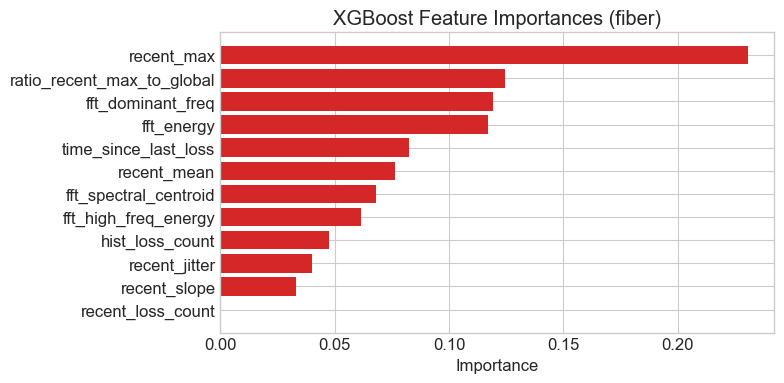

In [38]:
# --- Fiber Feature Importance (final plot)
tunnel = 'fiber'
train_dfs = train_dfs_dict.get(tunnel, [])

if not train_dfs:
    print('[FeatureImp] No training data available for Fiber, skipping.')
else:
    X_df, X_seq, y = process_dataset_all(train_dfs, N, X)
    if X_df.empty or len(y) == 0:
        print('[FeatureImp] No extracted features for Fiber, skipping.')
    else:
        if tunnel == 'fiber':
            cols_to_drop = ['mean', 'jitter', 'max', 'q95', 'ratio_recent_mean_to_global', 'spikes_over_q95']
        else:
            cols_to_drop = []

        cols_to_drop_actual = [c for c in cols_to_drop if c in X_df.columns]
        X_df_proc = X_df.drop(columns=cols_to_drop_actual) if cols_to_drop_actual else X_df.copy()

        scaler = StandardScaler()
        X_scaled = pd.DataFrame(scaler.fit_transform(X_df_proc), columns=X_df_proc.columns)

        num_neg = int((y == 0).sum())
        num_pos = int((y == 1).sum())

        if num_pos > 5:
            target_neg = max(10000, num_pos)
            target_neg = min(target_neg, num_neg)

            rus = RandomUnderSampler(sampling_strategy={0: target_neg, 1: num_pos}, random_state=42)
            X_rus, y_rus = rus.fit_resample(X_scaled, y)

            smote = SMOTE(sampling_strategy={0: target_neg, 1: target_neg}, random_state=42)
            X_train_final, y_train_final = smote.fit_resample(X_rus, y_rus)
        else:
            X_train_final, y_train_final = X_scaled, y

        xgb_params = {'use_label_encoder': False, 'eval_metric': 'logloss', 'n_jobs': -1, 'n_estimators': 50}
        model = xgb.XGBClassifier(**xgb_params)
        model.fit(X_train_final, y_train_final)

        fi = model.feature_importances_
        fi_df = pd.DataFrame({'feature': X_train_final.columns, 'importance': fi})
        fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

        top_k = min(20, len(fi_df))
        fig, ax = plt.subplots(figsize=(8, max(4, 0.25 * top_k)))
        ax.barh(fi_df['feature'].head(top_k)[::-1], fi_df['importance'].head(top_k)[::-1], color='#d62728')
        ax.set_xlabel('Importance')
        ax.set_title('XGBoost Feature Importances (fiber)')
        plt.tight_layout()
        outp = os.path.join(results_dir, 'feature_importance_fiber.png')
        plt.savefig(outp, dpi=300)
        print(f'[FeatureImp] Saved: {outp}')
        plt.show()

    -> Processing file 1/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 30.94 ms
    -> Processing file 2/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 48.39 ms
    -> Processing file 3/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 30.47 ms
    -> Processing file 4/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 35.53 ms
    -> Processing file 5/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 41.09 ms
    -> Processing file 6/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 29.46 ms
    -> Processing file 7/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 42.94 ms
    -> Processing file 8/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 93.78 ms
    -> Processing file 9/16 with 23450 original rows...
       Max delay

c:\Users\Pietro Guidetti\Documents\Portables\conda_installation\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:41:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,feature,importance,importance_pct
0,recent_max,0.230584,23.851604
1,ratio_recent_max_to_global,0.124555,12.883958
2,fft_dominant_freq,0.119114,12.321136
3,fft_energy,0.116884,12.090491
4,time_since_last_loss,0.082385,8.521848
5,recent_mean,0.076330,7.895530
6,fft_spectral_centroid,0.068061,7.040251
7,fft_high_freq_energy,0.061358,6.346890
8,hist_loss_count,0.047549,4.918449
9,recent_jitter,0.039925,4.129843



=== FIBER permutation importance ===


,feature,importance,std
0,fft_dominant_freq,0.18525,0.002051
1,ratio_recent_max_to_global,0.13069,0.001638
2,fft_spectral_centroid,0.10950,0.000666
3,fft_energy,0.10853,0.001303
4,recent_max,0.10367,0.000630
5,recent_mean,0.07552,0.001553
6,fft_high_freq_energy,0.06104,0.001084
7,recent_jitter,0.04275,0.001482
8,recent_slope,0.02450,0.000307
9,time_since_last_loss,0.00162,0.000211


    -> Processing file 1/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 840.82 ms
    -> Processing file 2/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 487.51 ms
    -> Processing file 3/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 646.33 ms
    -> Processing file 4/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 856.74 ms
    -> Processing file 5/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 836.31 ms
    -> Processing file 6/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 791.03 ms
    -> Processing file 7/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 457.76 ms
    -> Processing file 8/16 with 11344 original rows...
       Max delay calculated for Link Down penalty: 452.10 ms
    -> Processing file 9/16 with 23450 original rows...
       M

c:\Users\Pietro Guidetti\Documents\Portables\conda_installation\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:42:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,feature,importance,importance_pct
0,recent_mean,0.308339,34.162163
1,time_since_last_loss,0.245840,27.237610
2,fft_dominant_freq,0.059649,6.608748
3,max,0.053583,5.936715
4,q95,0.046446,5.145981
5,fft_energy,0.045077,4.994255
6,ratio_recent_max_to_global,0.038083,4.219358
7,recent_max,0.037158,4.116841
8,fft_spectral_centroid,0.034755,3.850646
9,mean,0.033645,3.727682



=== MOBILE permutation importance ===


,feature,importance,std
0,recent_mean,0.12972,0.001687
1,max,0.10494,0.001529
2,fft_spectral_centroid,0.08492,0.002763
3,fft_dominant_freq,0.07569,0.001187
4,mean,0.06147,0.001306
5,q95,0.05920,0.001007
6,recent_max,0.05663,0.002086
7,ratio_recent_max_to_global,0.04310,0.001769
8,time_since_last_loss,0.03708,0.001434
9,jitter,0.03575,0.000277


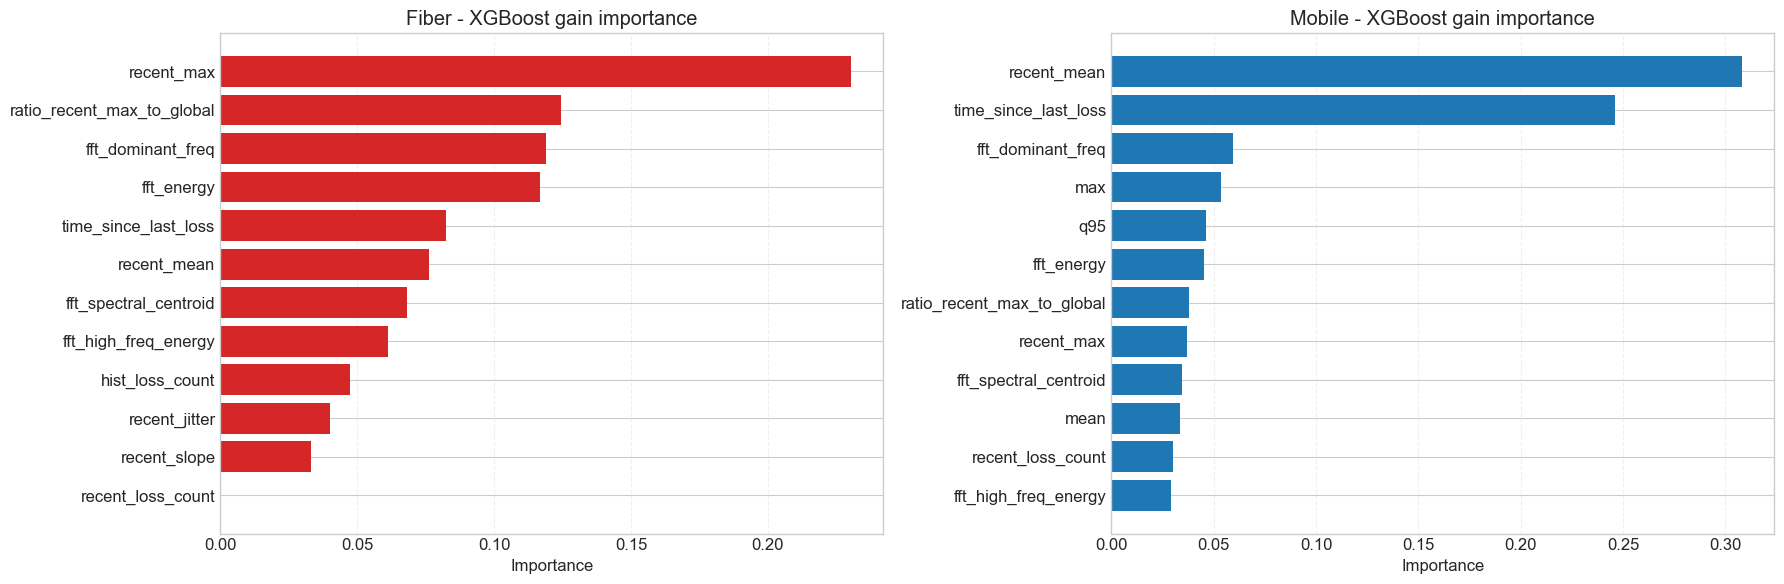

In [39]:
# --- Compare Fiber vs Mobile feature importances on the same scale ---
from sklearn.inspection import permutation_importance
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def build_training_matrix_for_tunnel(tunnel_name):
    train_dfs = train_dfs_dict.get(tunnel_name, [])
    if not train_dfs:
        return None, None, None

    X_df, _, y = process_dataset_all(train_dfs, N, X)
    if X_df.empty or len(y) == 0:
        return None, None, None

    if tunnel_name == 'fiber':
        cols_to_drop = ['mean', 'jitter', 'max', 'q95', 'ratio_recent_mean_to_global', 'spikes_over_q95']
    elif tunnel_name == 'mobile':
        cols_to_drop = ['recent_jitter', 'recent_slope', 'ratio_recent_mean_to_global', 'spikes_over_q95']
    else:
        cols_to_drop = []

    cols_to_drop_actual = [c for c in cols_to_drop if c in X_df.columns]
    X_df_proc = X_df.drop(columns=cols_to_drop_actual) if cols_to_drop_actual else X_df.copy()
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_df_proc), columns=X_df_proc.columns)

    num_neg = int((y == 0).sum())
    num_pos = int((y == 1).sum())

    if num_pos > 5:
        target_neg = max(10000, num_pos)
        target_neg = min(target_neg, num_neg)
        rus = RandomUnderSampler(sampling_strategy={0: target_neg, 1: num_pos}, random_state=42)
        X_rus, y_rus = rus.fit_resample(X_scaled, y)
        smote = SMOTE(sampling_strategy={0: target_neg, 1: target_neg}, random_state=42)
        X_train_final, y_train_final = smote.fit_resample(X_rus, y_rus)
    else:
        X_train_final, y_train_final = X_scaled, y

    return X_train_final, y_train_final, X_df_proc.columns

results = {}
for tunnel_name in ['fiber', 'mobile']:
    X_train_final, y_train_final, feature_names = build_training_matrix_for_tunnel(tunnel_name)
    if X_train_final is None:
        print(f'[ImportanceCheck] No data for {tunnel_name}')
        continue

    model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_jobs=-1, n_estimators=50, random_state=42)
    model.fit(X_train_final, y_train_final)

    gain_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    top_features = gain_importance.head(10).copy()
    top_features['importance_pct'] = top_features['importance'] / top_features['importance'].sum() * 100
    results[tunnel_name] = {
        'model': model,
        'X': X_train_final,
        'y': y_train_final,
        'features': feature_names,
        'gain': gain_importance,
    }

    print(f'\n=== {tunnel_name.upper()} raw gain importance ===')
    display(top_features)

    perm = permutation_importance(model, X_train_final, y_train_final, n_repeats=5, random_state=42, n_jobs=-1)
    perm_df = pd.DataFrame({
        'feature': feature_names,
        'importance': perm.importances_mean,
        'std': perm.importances_std,
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    print(f'\n=== {tunnel_name.upper()} permutation importance ===')
    display(perm_df.head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)
for ax, tunnel_name, color in [(axes[0], 'fiber', '#d62728'), (axes[1], 'mobile', '#1f77b4')]:
    gain_df = results[tunnel_name]['gain'].head(12).iloc[::-1]
    ax.barh(gain_df['feature'], gain_df['importance'], color=color)
    ax.set_title(f'{tunnel_name.capitalize()} - XGBoost gain importance')
    ax.set_xlabel('Importance')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'feature_importance_fiber_mobile_compare.png'), dpi=300)
plt.show()

c:\Users\Pietro Guidetti\Documents\Portables\conda_installation\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== FIBER SHAP summary (shap) ===


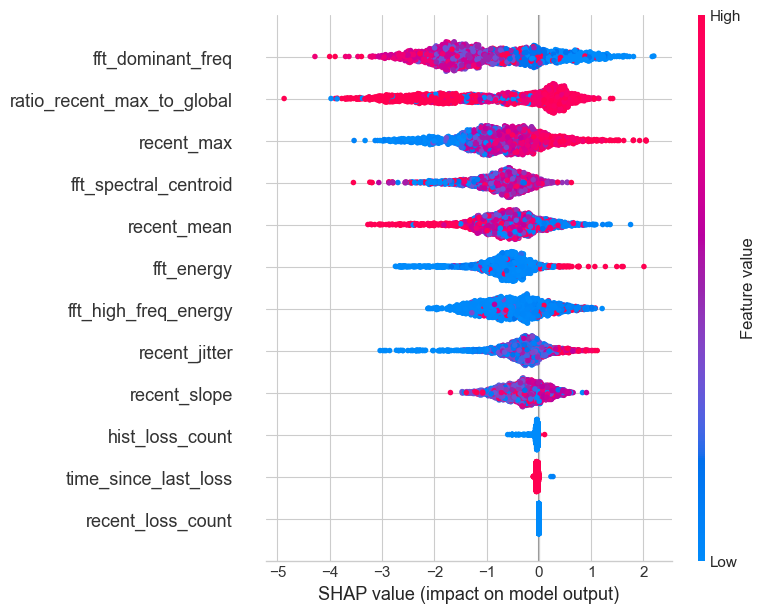


=== FIBER mean(|SHAP|) ===
                   feature  mean_abs_shap
         fft_dominant_freq       1.176851
ratio_recent_max_to_global       1.106917
                recent_max       0.865527
     fft_spectral_centroid       0.756931
               recent_mean       0.710199
                fft_energy       0.676110
      fft_high_freq_energy       0.637130
             recent_jitter       0.413643
              recent_slope       0.392175
           hist_loss_count       0.050670


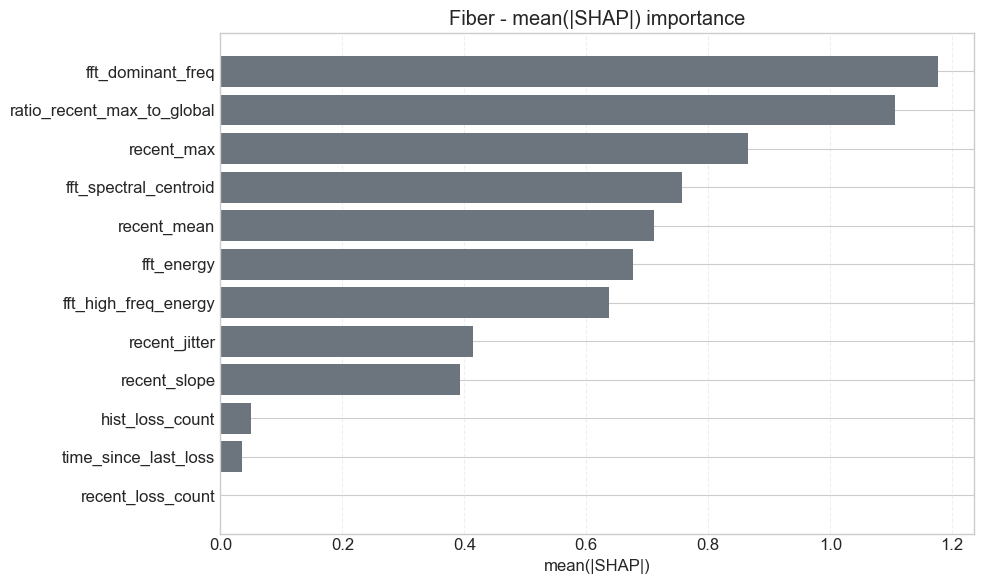

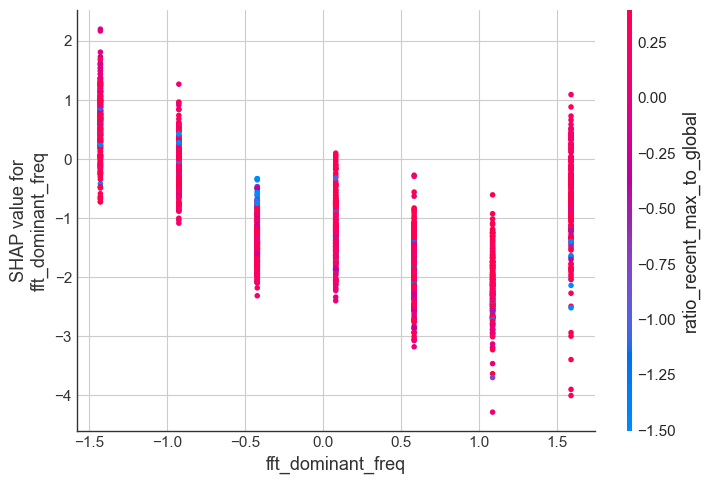


=== MOBILE SHAP summary (shap) ===


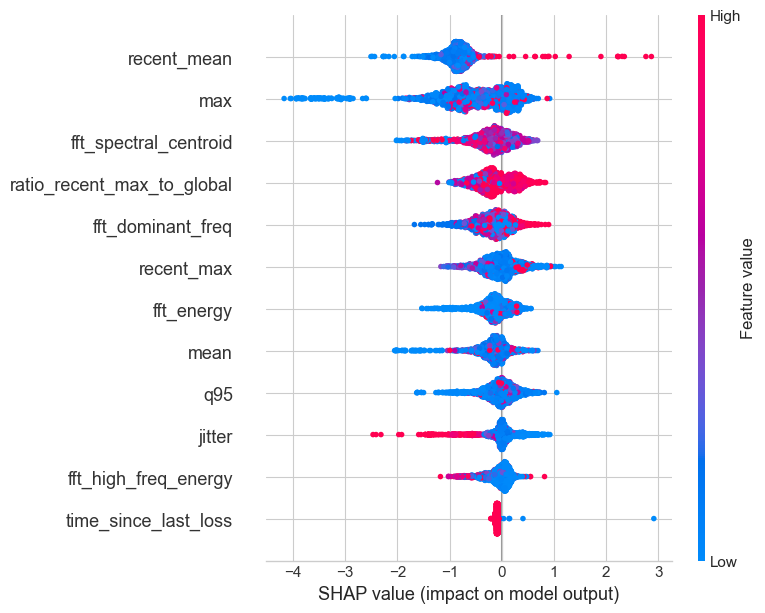


=== MOBILE mean(|SHAP|) ===
                   feature  mean_abs_shap
               recent_mean       0.854260
                       max       0.649445
     fft_spectral_centroid       0.333903
ratio_recent_max_to_global       0.304418
         fft_dominant_freq       0.283890
                recent_max       0.251590
                fft_energy       0.235381
                      mean       0.231372
                       q95       0.220755
                    jitter       0.218576


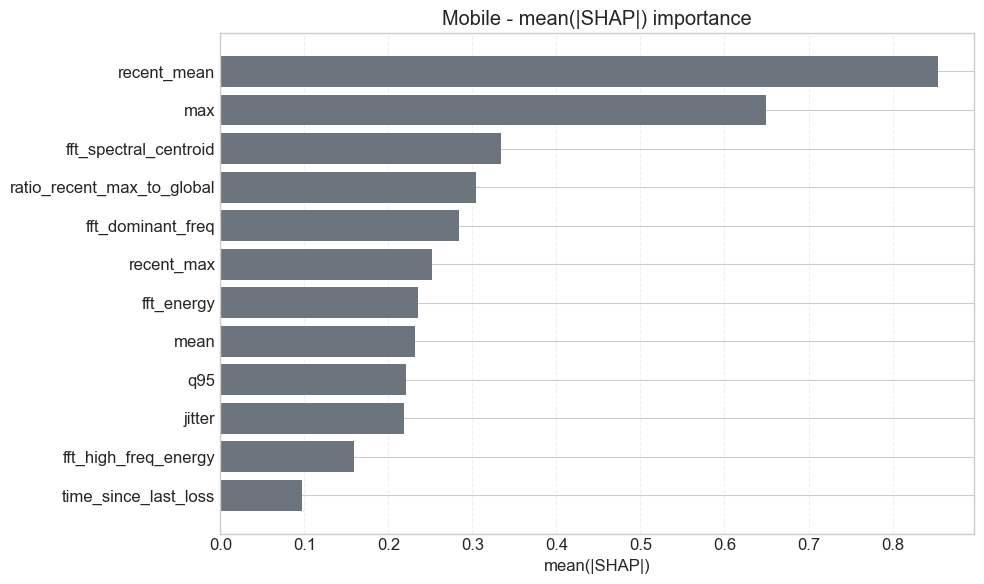

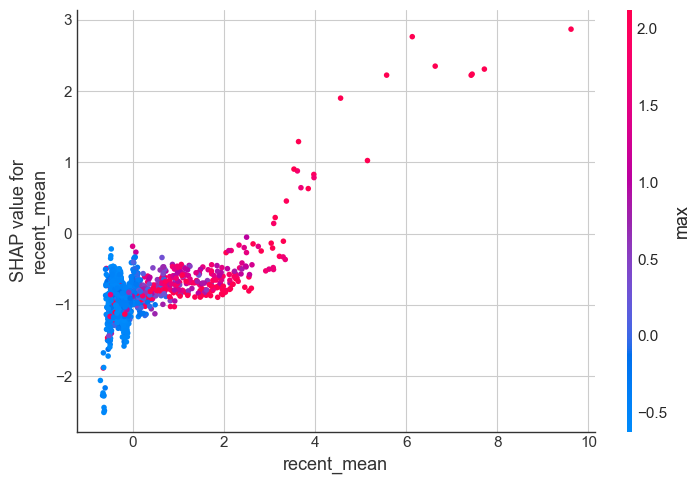

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

try:
    import shap
except ImportError:
    shap = None

shap_dir = os.path.join(results_dir, 'shap')
os.makedirs(shap_dir, exist_ok=True)


def _select_shap_matrix(shap_values):
    if isinstance(shap_values, list):
        return shap_values[1] if len(shap_values) > 1 else shap_values[0]
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        return shap_values[:, :, 1] if shap_values.shape[2] > 1 else shap_values[:, :, 0]
    return shap_values


def _compute_shap_values(model, X_sample, feature_names):
    if shap is not None:
        explainer = shap.TreeExplainer(model)
        return _select_shap_matrix(explainer.shap_values(X_sample)), 'shap'

    booster = model.get_booster()
    contribs = booster.predict(xgb.DMatrix(X_sample, feature_names=feature_names), pred_contribs=True)
    return contribs[:, :-1], 'xgboost_contrib'


for tunnel_name in ['fiber', 'mobile']:
    if tunnel_name not in results:
        print(f'[SHAP] No trained model available for {tunnel_name}')
        continue

    model = results[tunnel_name]['model']
    X_shap = results[tunnel_name]['X']
    feature_names = list(results[tunnel_name]['features'])
    sample_size = min(2000, len(X_shap))
    X_sample = X_shap.iloc[:sample_size].copy() if hasattr(X_shap, 'iloc') else X_shap[:sample_size].copy()

    shap_values, backend = _compute_shap_values(model, X_sample, feature_names)

    print(f'\n=== {tunnel_name.upper()} SHAP summary ({backend}) ===')
    if backend == 'shap':
        shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False, max_display=12)
        plt.tight_layout()
        plt.savefig(os.path.join(shap_dir, f'shap_summary_{tunnel_name}.png'), dpi=300, bbox_inches='tight')
        plt.show()
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        order = np.argsort(mean_abs_shap)[::-1][:12]
        top_features = [feature_names[i] for i in order][::-1]
        top_values = mean_abs_shap[order][::-1]
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.barh(top_features, top_values, color='#6c757d')
        ax.set_title(f'{tunnel_name.capitalize()} - mean(|SHAP|) summary')
        ax.set_xlabel('mean(|SHAP|)')
        ax.grid(axis='x', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(shap_dir, f'shap_summary_{tunnel_name}.png'), dpi=300, bbox_inches='tight')
        plt.show()

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.DataFrame({
        'feature': feature_names,
        'mean_abs_shap': mean_abs_shap,
    }).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

    print(f'\n=== {tunnel_name.upper()} mean(|SHAP|) ===')
    print(shap_importance.head(10).to_string(index=False))

    top_shap = shap_importance.head(12).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_shap['feature'], top_shap['mean_abs_shap'], color='#6c757d')
    ax.set_title(f'{tunnel_name.capitalize()} - mean(|SHAP|) importance')
    ax.set_xlabel('mean(|SHAP|)')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(shap_dir, f'shap_importance_{tunnel_name}.png'), dpi=300, bbox_inches='tight')
    plt.show()

    if len(top_shap) >= 2:
        top_feature = top_shap['feature'].iloc[-1]
        interaction_feature = top_shap['feature'].iloc[-2]

        if backend == 'shap':
            shap.dependence_plot(
                top_feature,
                shap_values,
                X_sample,
                feature_names=feature_names,
                interaction_index=interaction_feature,
                show=False,
            )
        else:
            top_idx = feature_names.index(top_feature)
            fig, ax = plt.subplots(figsize=(10, 6))
            scatter = ax.scatter(
                X_sample[top_feature],
                shap_values[:, top_idx],
                c=X_sample[interaction_feature],
                cmap='coolwarm',
                s=16,
                alpha=0.75,
            )
            ax.set_xlabel(top_feature)
            ax.set_ylabel(f'SHAP value for {top_feature}')
            ax.set_title(f'{tunnel_name.capitalize()} - dependence plot for {top_feature}')
            fig.colorbar(scatter, ax=ax, label=interaction_feature)

        plt.tight_layout()
        plt.savefig(os.path.join(shap_dir, f'shap_dependence_{tunnel_name}_{top_feature}.png'), dpi=300, bbox_inches='tight')
        plt.show()


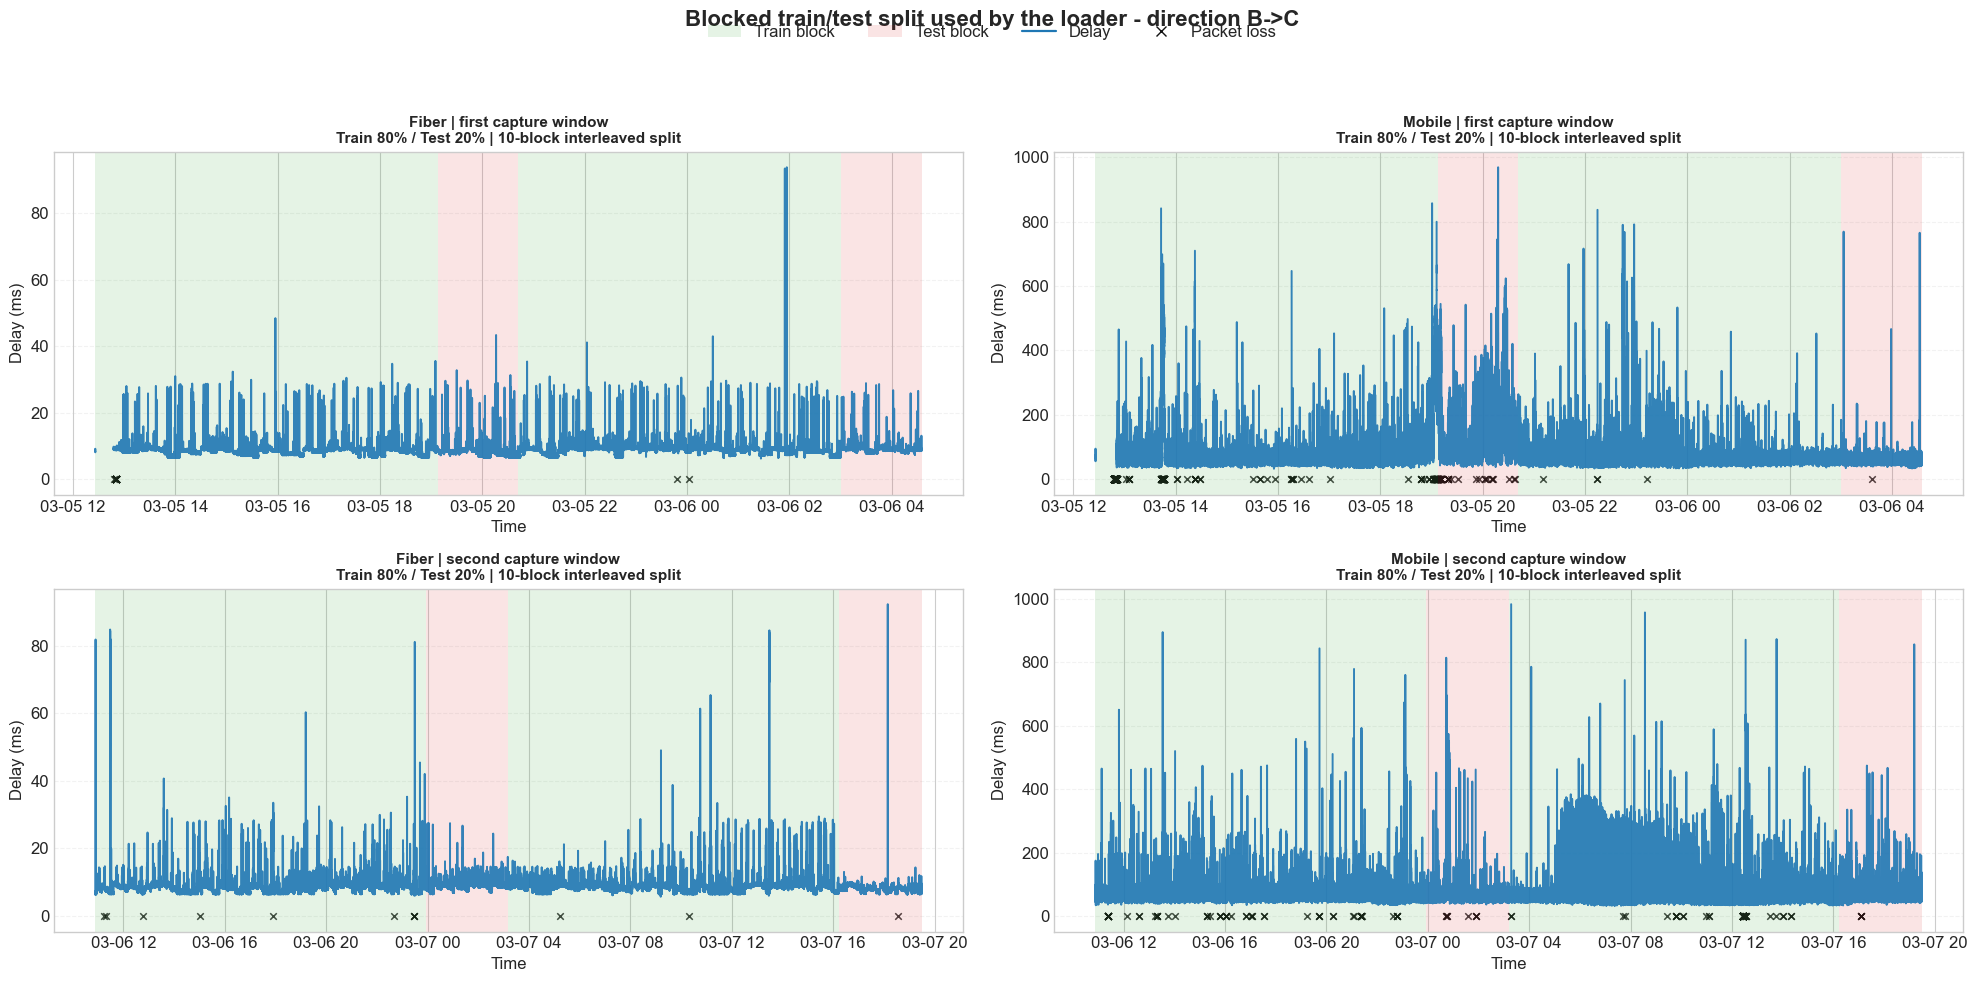

Saved visualization to: results/raw_data_visualization\train_test_split_visualization.png


In [41]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from src.data_loader import get_file_paths

split_config = config.get('train_test_split', {})
if not split_config:
    print('No train_test_split section found in the loaded config.')
else:
    direction = next(iter(split_config.keys()))
    split_info = split_config[direction]
    train_pcts = split_info.get('train', [0, 0])
    test_pcts = split_info.get('test', [0, 0])

    file_paths = get_file_paths(DATASET_DIR, direction)
    if not file_paths:
        print(f'No CSV files found for direction {direction}.')
    else:
        window_order = {'first_capture_window': 0, 'second_capture_window': 1}
        file_paths = sorted(
            file_paths,
            key=lambda item: (window_order.get(item[0], 99), 0 if 'fiber' in item[1] else 1)
        )

        fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex=False, sharey=False)
        axes = axes.flatten()

        train_color = '#2ca02c'
        test_color = '#d62728'
        delay_color = '#1f77b4'

        for ax, (window_name, file_path) in zip(axes, file_paths):
            df = pd.read_csv(file_path)
            df['time'] = pd.to_datetime(df['time'])
            df = df.sort_values('time').reset_index(drop=True)

            window_idx = 0 if window_name == 'first_capture_window' else 1
            train_pct = train_pcts[window_idx] / 100.0
            test_pct = test_pcts[window_idx] / 100.0
            total_pct = train_pct + test_pct

            if total_pct <= 0:
                ax.set_title(f'{window_name} - no split configured')
                ax.axis('off')
                continue

            test_ratio = test_pct / total_pct
            test_interval = max(1, int(1 / test_ratio)) if test_ratio > 0 else 999

            n_chunks = 10
            chunk_size = len(df) // n_chunks

            delay_series = df['delay_ms'].replace(-1, np.nan)
            ax.plot(df['time'], delay_series, color=delay_color, linewidth=1.4, alpha=0.9)

            loss_mask = df['delay_ms'] == -1
            if loss_mask.any():
                ax.scatter(
                    df.loc[loss_mask, 'time'],
                    np.zeros(loss_mask.sum()),
                    color='#111111',
                    marker='x',
                    s=22,
                    linewidths=1.1,
                    alpha=0.8
                )

            for c in range(n_chunks):
                start = c * chunk_size
                end = (c + 1) * chunk_size if c < n_chunks - 1 else len(df)
                chunk_df = df.iloc[start:end]
                if chunk_df.empty:
                    continue

                is_test = test_pct > 0 and (c + 1) % test_interval == 0
                span_color = test_color if is_test else train_color
                ax.axvspan(
                    chunk_df['time'].iloc[0],
                    chunk_df['time'].iloc[-1],
                    color=span_color,
                    alpha=0.12,
                    linewidth=0
                )

            tech_name = 'Fiber' if 'fiber' in file_path.lower() else 'Mobile'
            ax.set_title(
                f'{tech_name} | {window_name.replace("_", " ")}\n'
                f'Train {train_pct * 100:.0f}% / Test {test_pct * 100:.0f}% | 10-block interleaved split',
                fontsize=11,
                weight='bold'
            )
            ax.set_xlabel('Time')
            ax.set_ylabel('Delay (ms)')
            ax.grid(True, axis='y', linestyle='--', alpha=0.25)

        for ax in axes[len(file_paths):]:
            ax.axis('off')

        legend_handles = [
            Patch(facecolor=train_color, alpha=0.12, label='Train block'),
            Patch(facecolor=test_color, alpha=0.12, label='Test block'),
            plt.Line2D([0], [0], color=delay_color, linewidth=1.6, label='Delay'),
            plt.Line2D([0], [0], color='#111111', marker='x', linestyle='None', markersize=7, label='Packet loss')
        ]

        fig.suptitle(
            f'Blocked train/test split used by the loader - direction {direction}',
            fontsize=16,
            weight='bold'
        )
        fig.legend(handles=legend_handles, loc='upper center', ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.98))
        plt.tight_layout(rect=(0, 0, 1, 0.93))
        out_path = os.path.join(results_dir, 'train_test_split_visualization.png')
        plt.savefig(out_path, dpi=300, bbox_inches='tight')
        plt.show()
        print(f'Saved visualization to: {out_path}')
